### Read ME
    
Before running the program, please make sure the library have installed on your environment. 
IF get the error ModuleNotFoundError: No module named"". That means the library has not been installed.
    
Using pip function install library.  
Example you got error like ModuleNotFoundError: No module named "wfdb". So put & run this code for install wfdb

       pip install "library name"
   
   <B>pip install wfdb</B> 

at new cell of jupyter notebook. Also use this code for install other library 
    
    

In [1]:
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import os
import shutil
import posixpath

import wfdb
from wfdb import processing
from PIL import Image
import pandas as pd

### ECG Preprocessing
#### First download all data  which can Access at:
    MIT-BIH Normal Sinus Rhythm Database https://physionet.org/content/nsrdb/1.0.0/
    Sudden Cardiac Death Holter Database https://physionet.org/content/sddb/1.0.0/

In [6]:
# function to read signals and convert in picture
def conv_topict(sig, peak_inds, fs, figsize=(20, 10), saveto=None):
    "Plot a signal with its peaks and heart rate"

    N = sig.shape[0]
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    
    ax.plot(sig, color='#3979f0', label='Signal')

    if saveto is not None:
        plt.savefig(saveto, dpi=400)
    plt.show()

### Preprocessing - Normal Dataset

In [7]:
# Read all of the record on Normal dataset
lines = []
with open('Data/mit-bih-normal-sinus-rhythm-database-1.0.0/RECORDS') as f:
    lines = f.readlines()[:-1]

for ii in range(0,len(lines)):
    lines[ii] = lines[ii][:-1]
    
lines

['16265',
 '16272',
 '16273',
 '16420',
 '16483',
 '16539',
 '16773',
 '16786',
 '16795',
 '17052',
 '17453',
 '18177',
 '18184',
 '19088',
 '19090',
 '19093',
 '19140']

In [8]:
# function for save the image
def saveImage(v, itr, directory, record, start, finish, folderName):
    # create new folder in Picture folder
    newpath = r'Picture/'+folderName+'/'+str(v) 
    if not os.path.exists(newpath):
        os.makedirs(newpath)

    # directory for saving file of grayscale
    saveto = "Picture/"+folderName+"/"+str(v)+"/"+str(itr)+".png"

    # Load the WFDB record and the physical samples
    record = wfdb.rdrecord(directory, sampfrom=start, sampto=finish, channels=[0])

    # Use the GQRS algorithm to detect QRS locations in the first channel
    qrs_inds = processing.qrs.gqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

    # Plot results
    conv_topict(sig=record.p_signal, peak_inds=qrs_inds, fs=record.fs, saveto=saveto)

    # open the image and save as grayscale picture
    img = Image.open(saveto).convert('L')

    # create new folder in Grayscale folder
    newpath = r'Grayscale/'+folderName+'/'+str(v) 
    if not os.path.exists(newpath):
        os.makedirs(newpath)

    save_img = "Grayscale/"+folderName+"/"+str(v)+"/"+str(itr)+".png"
    img.save(save_img)

    print('Finishing data '+str(v)+" "+str(itr))

Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16265


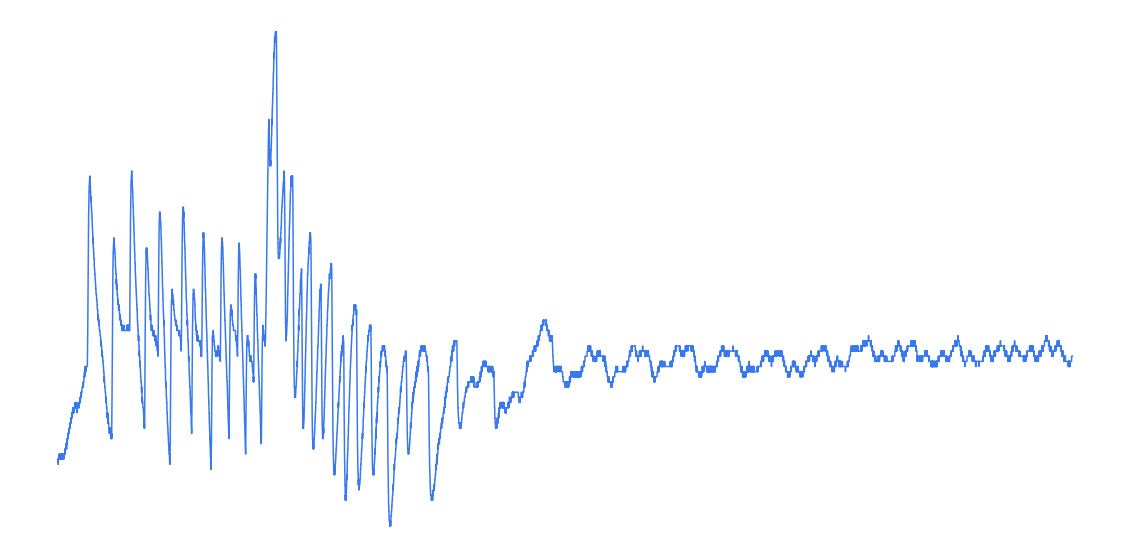

Finishing data 16265 1


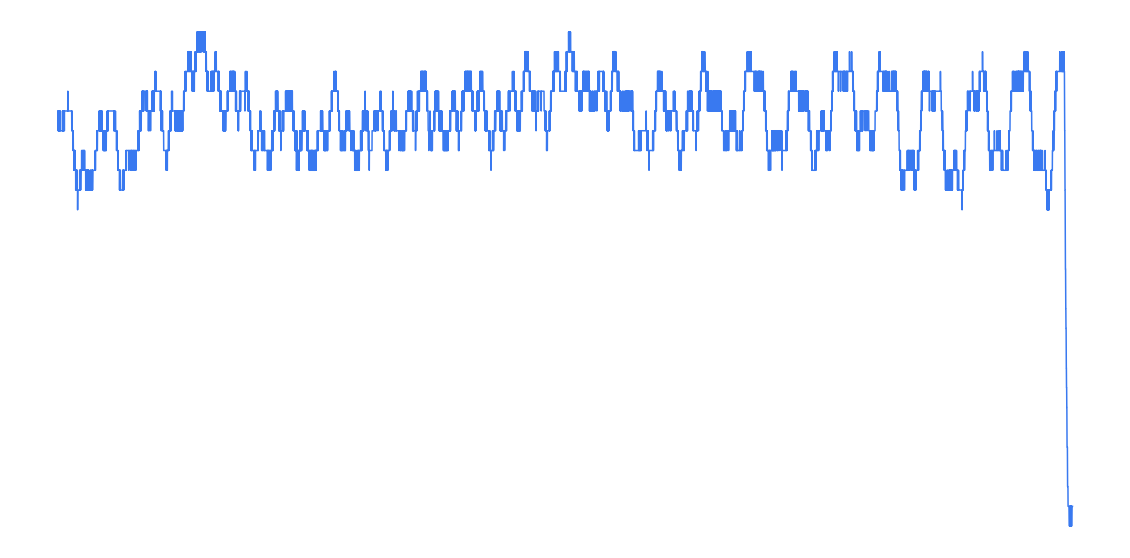

Finishing data 16265 2
Finishing data 16265
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16272


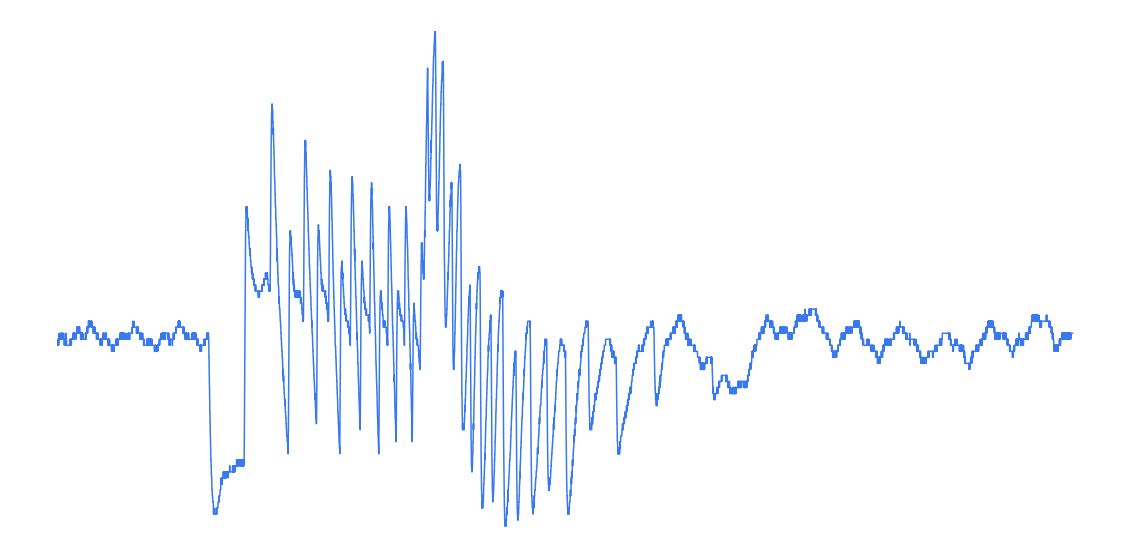

Finishing data 16272 1


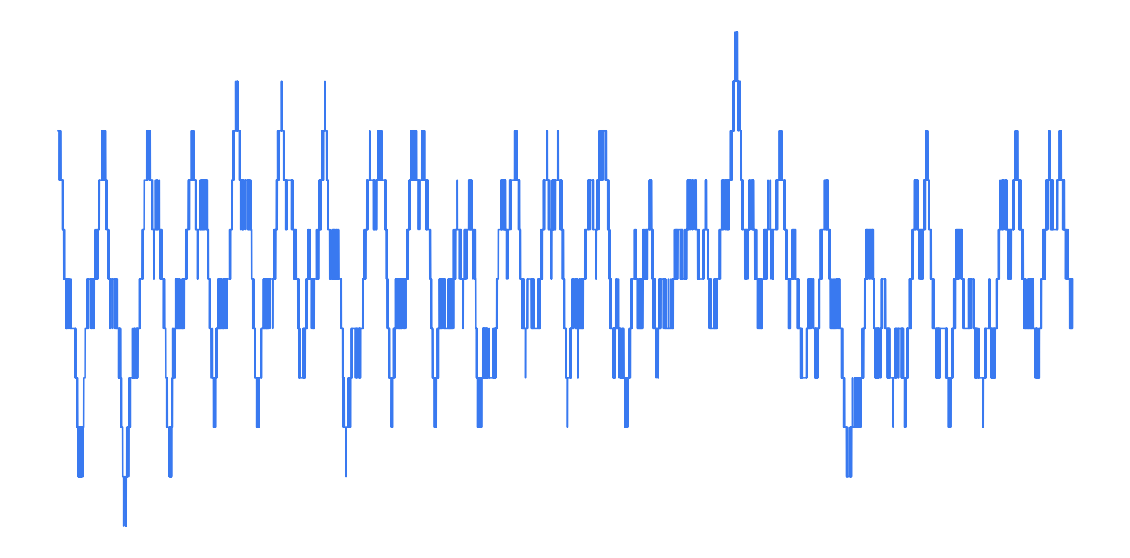

Finishing data 16272 2
Finishing data 16272
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16273


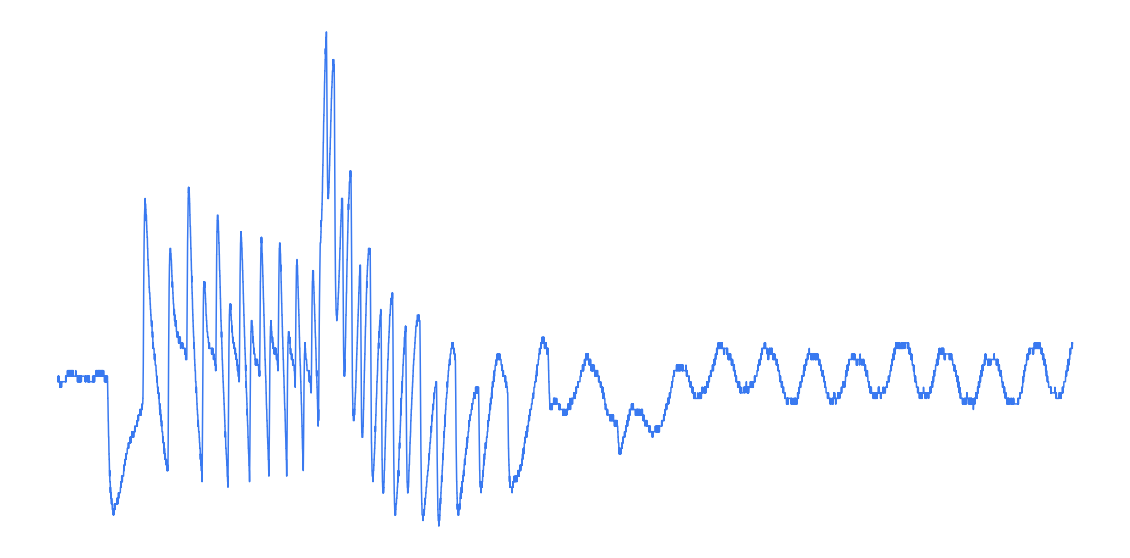

Finishing data 16273 1


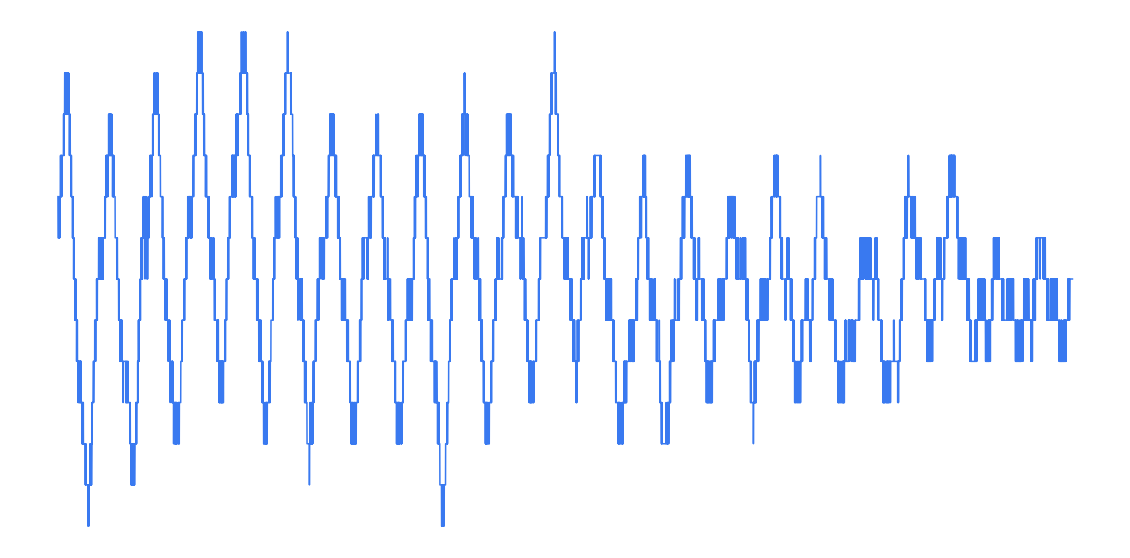

Finishing data 16273 2
Finishing data 16273
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16420


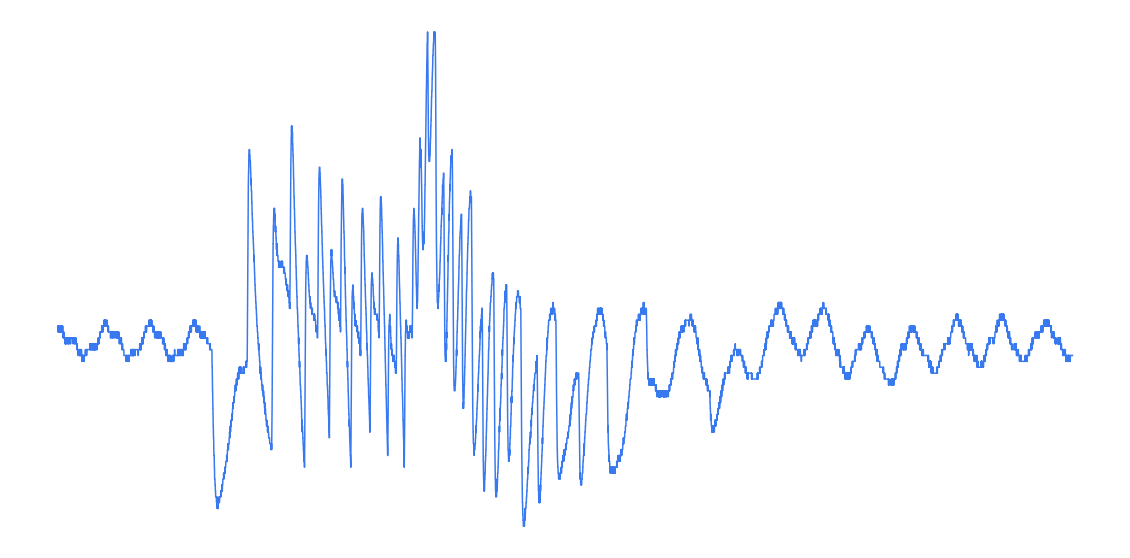

Finishing data 16420 1


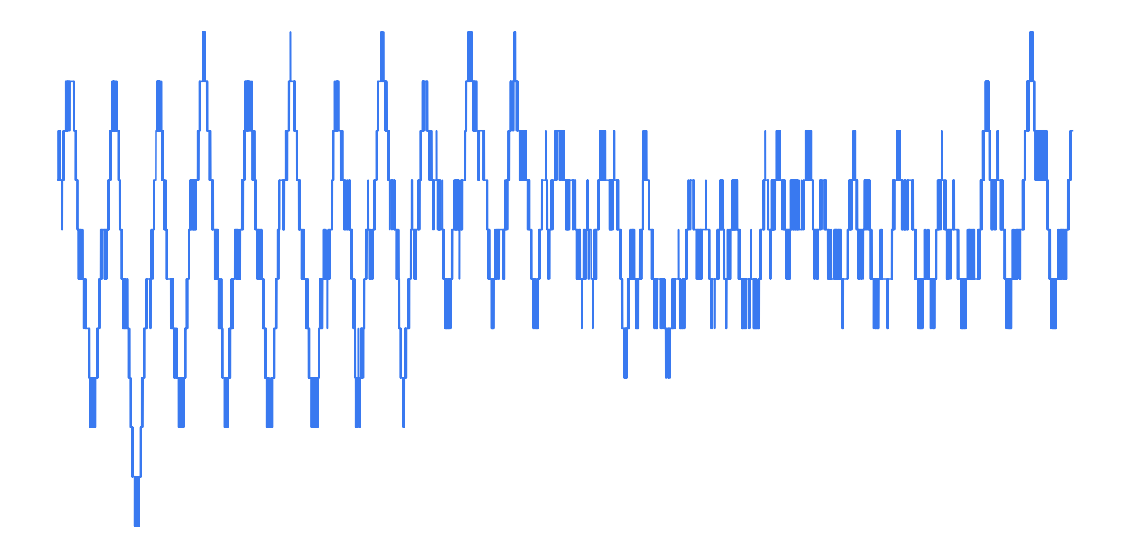

Finishing data 16420 2
Finishing data 16420
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16483


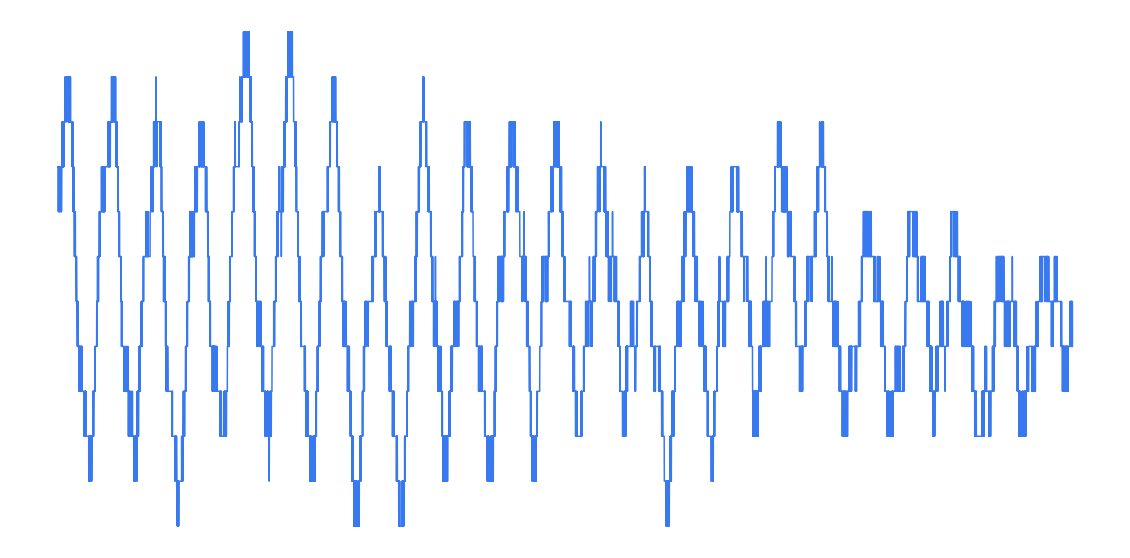

Finishing data 16483 1


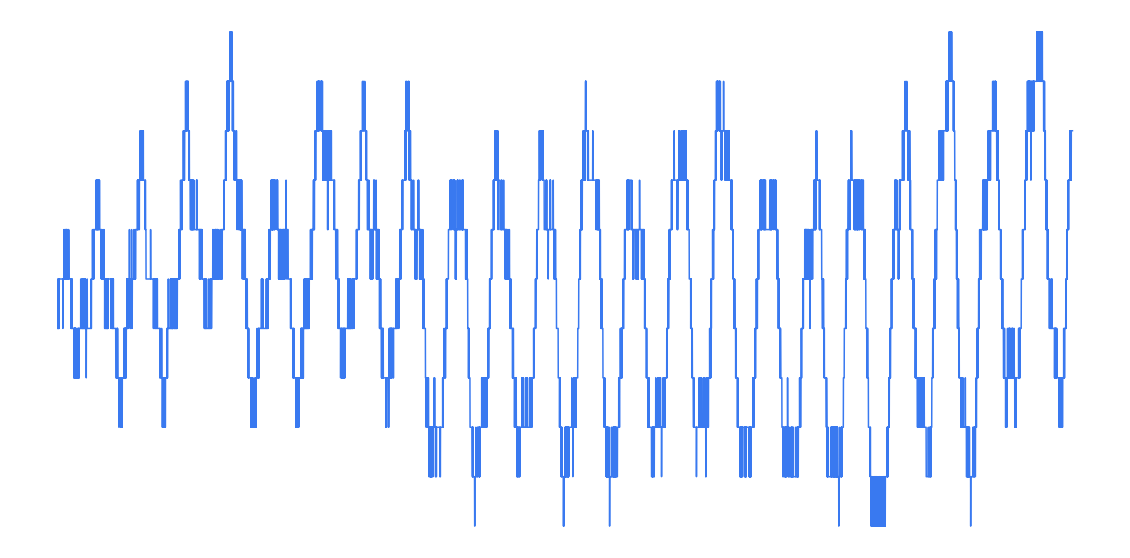

Finishing data 16483 2
Finishing data 16483
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16539


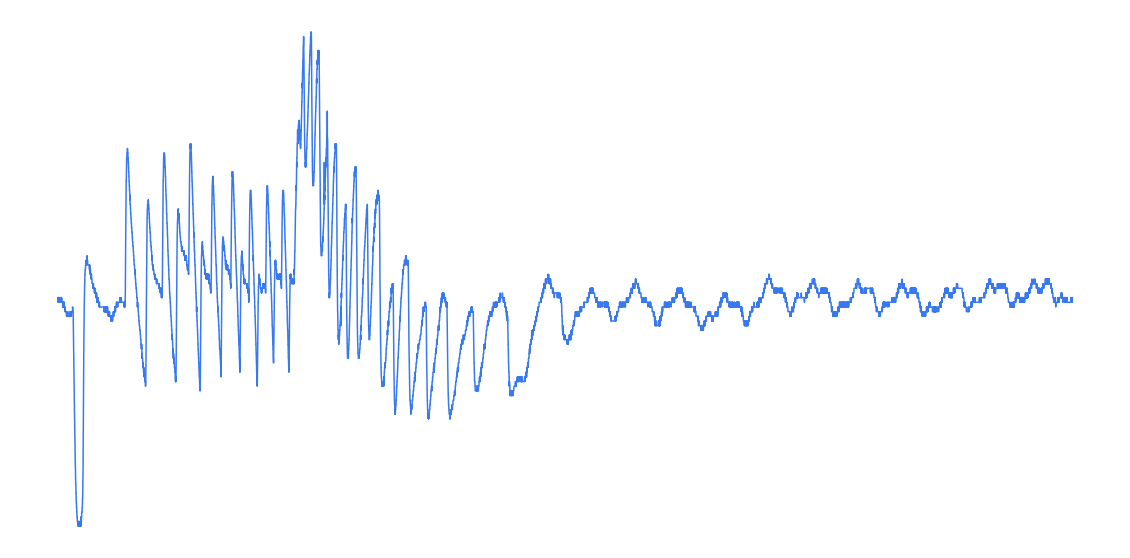

Finishing data 16539 1


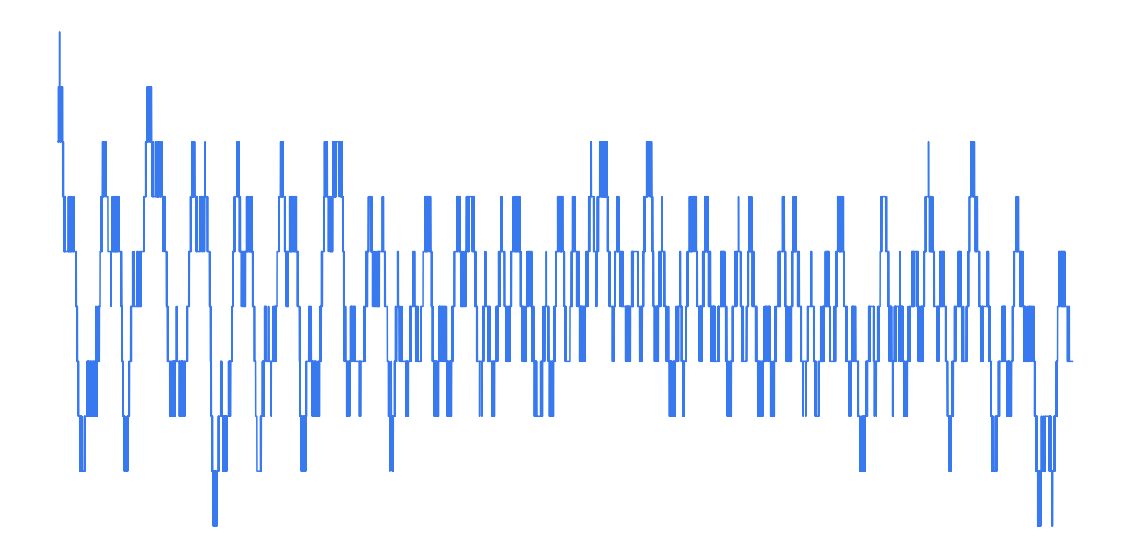

Finishing data 16539 2
Finishing data 16539
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16773


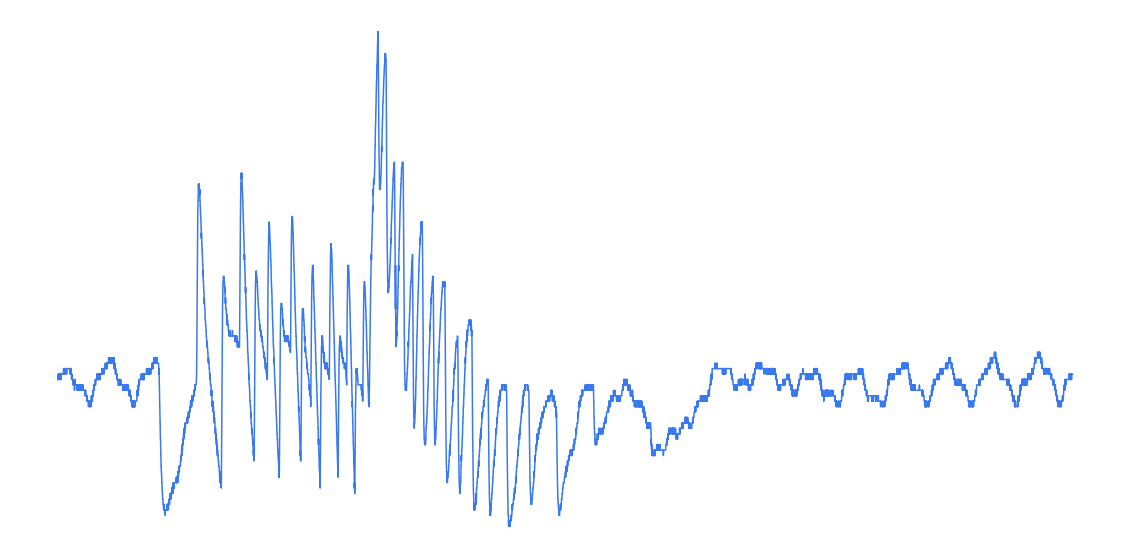

Finishing data 16773 1


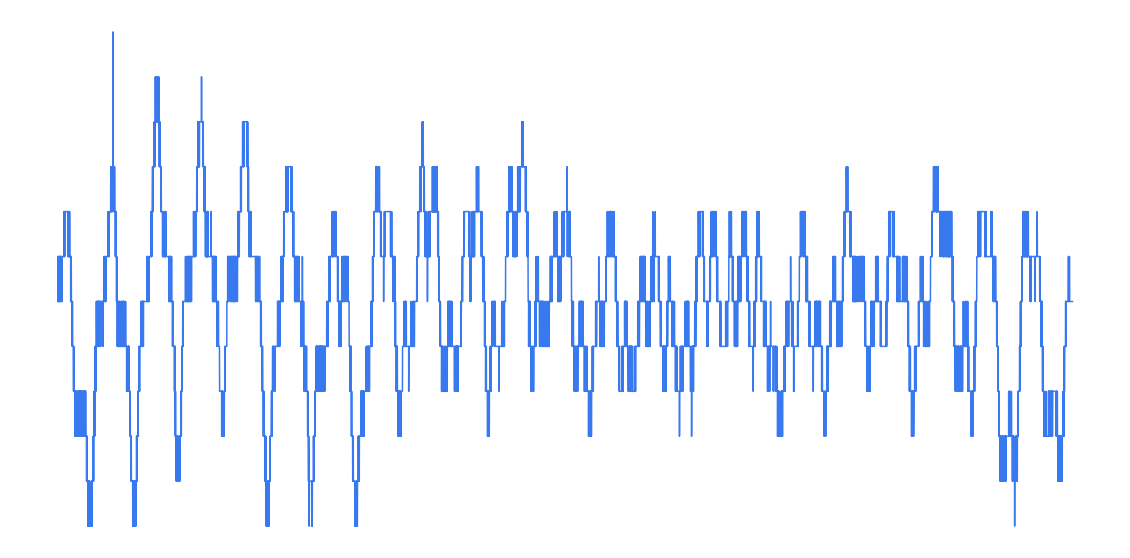

Finishing data 16773 2
Finishing data 16773
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16786


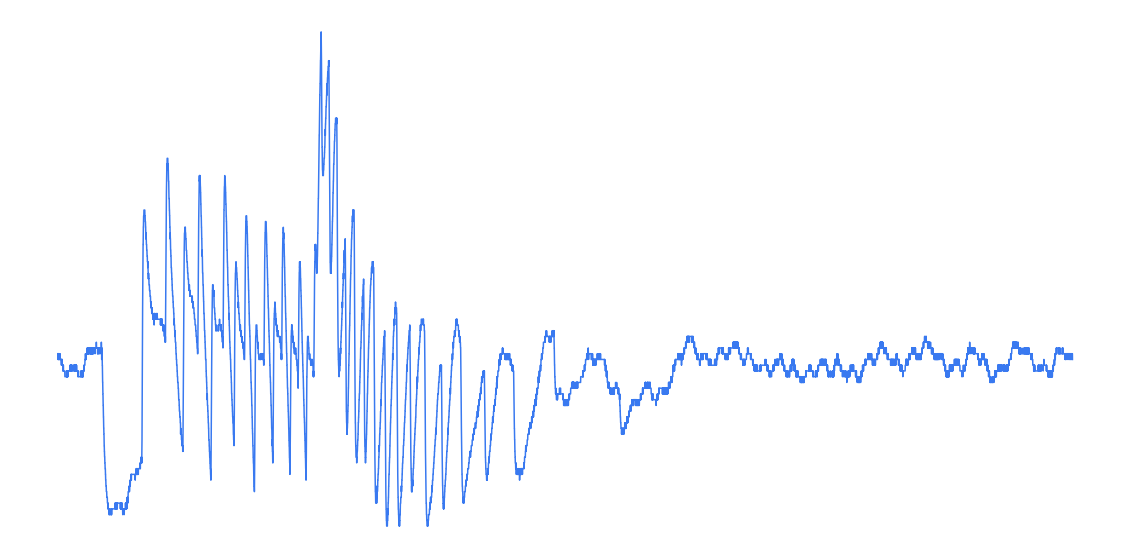

Finishing data 16786 1


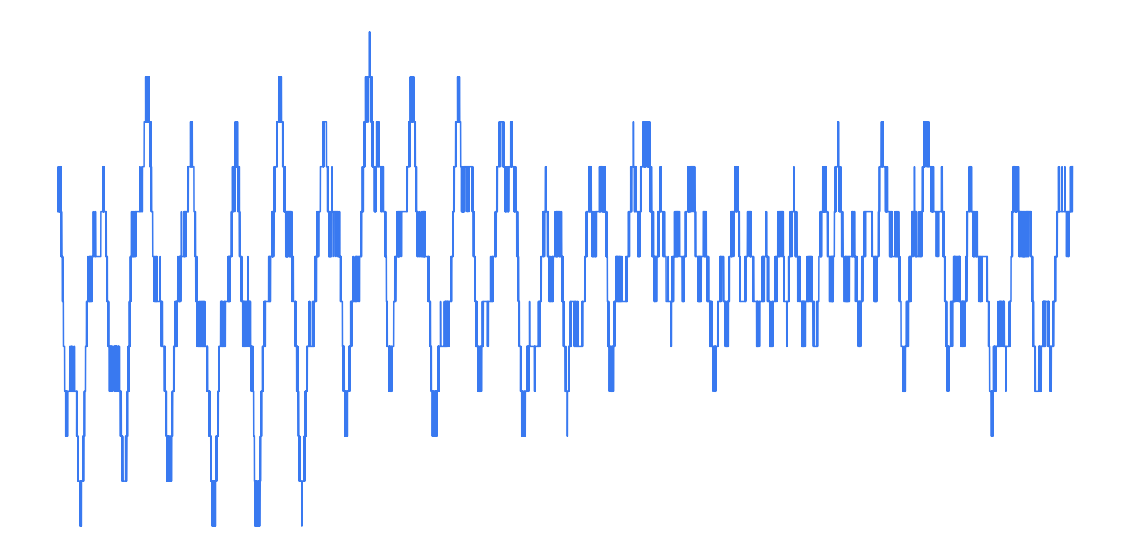

Finishing data 16786 2
Finishing data 16786
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/16795


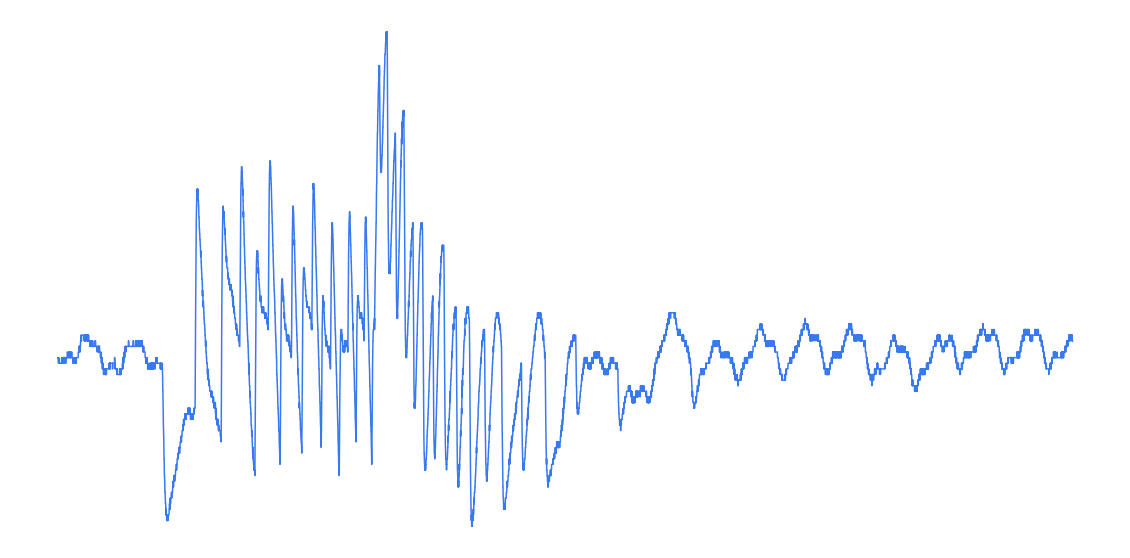

Finishing data 16795 1


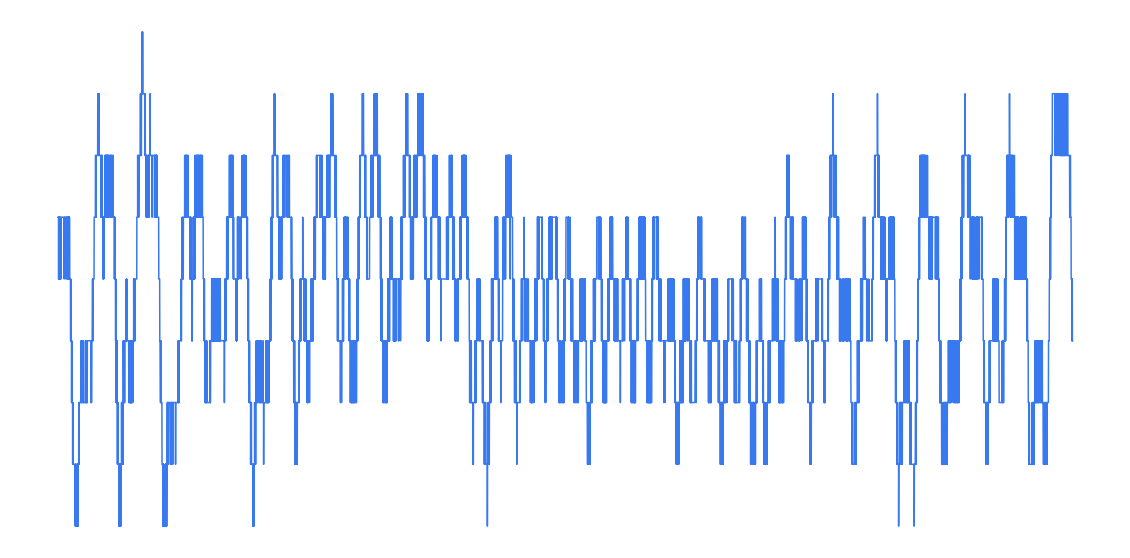

Finishing data 16795 2
Finishing data 16795
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/17052


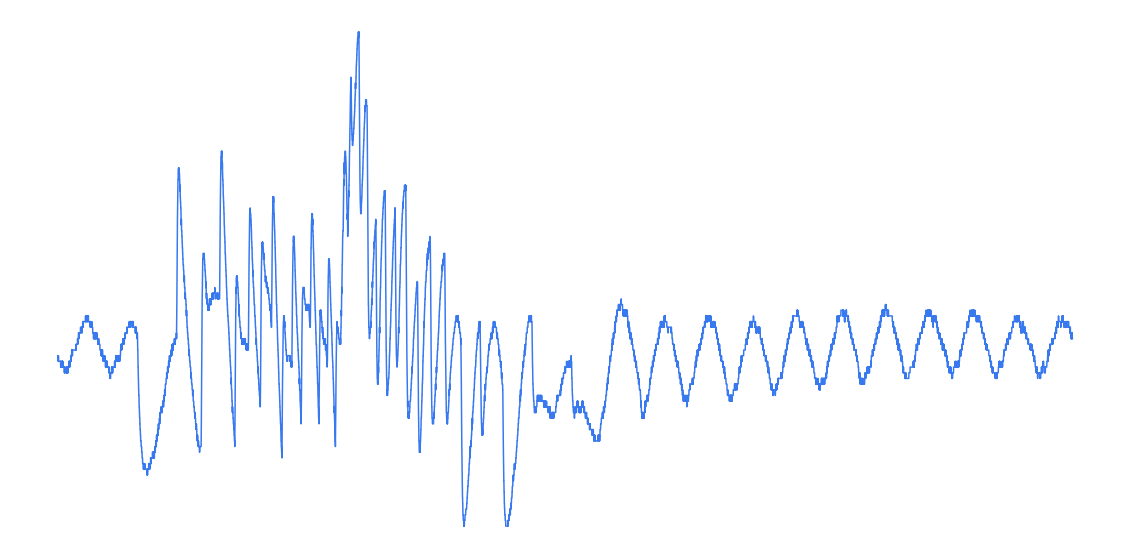

Finishing data 17052 1


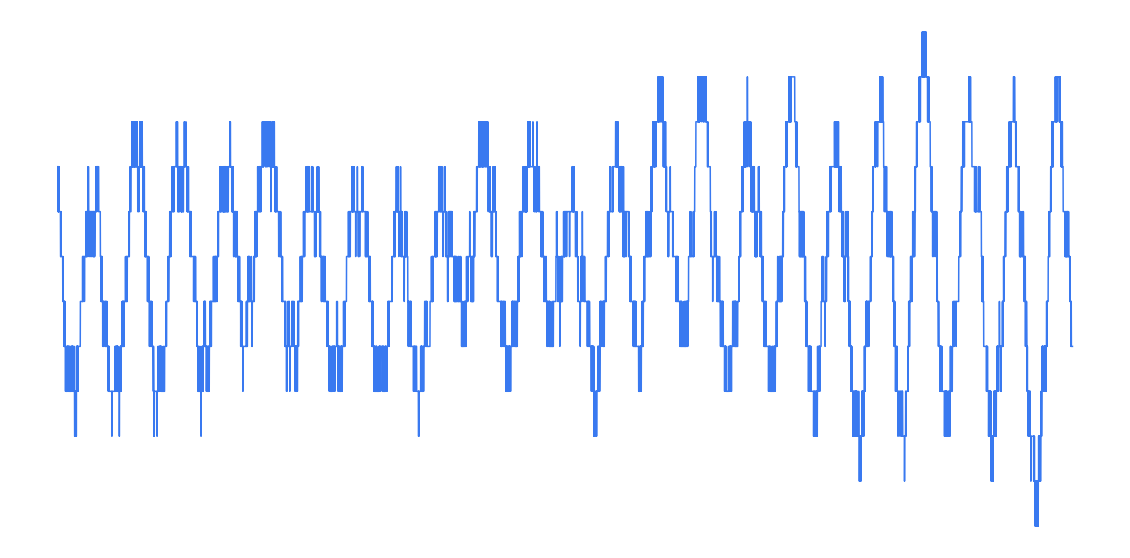

Finishing data 17052 2
Finishing data 17052
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/17453


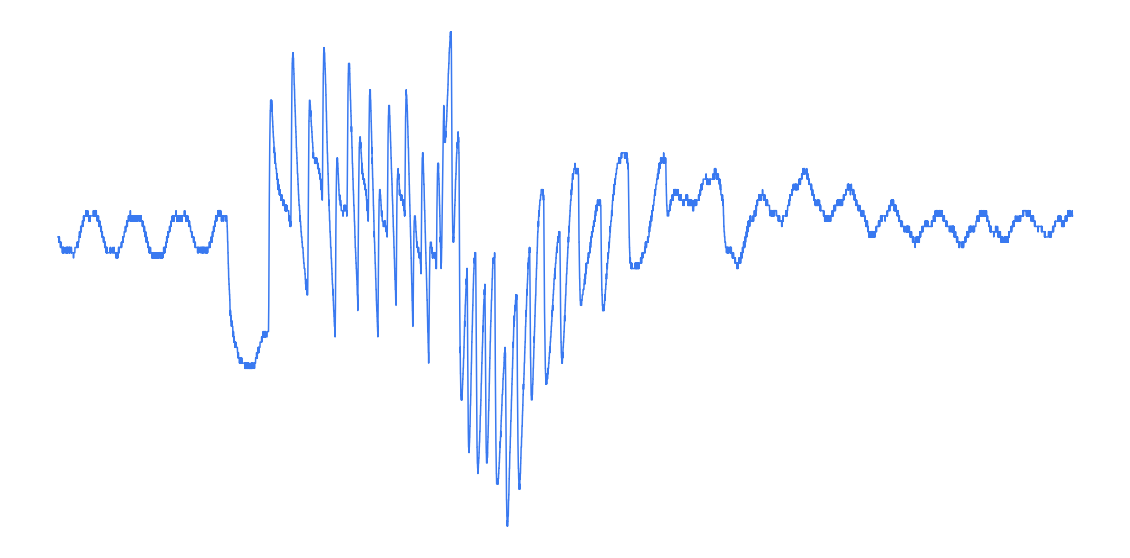

Finishing data 17453 1


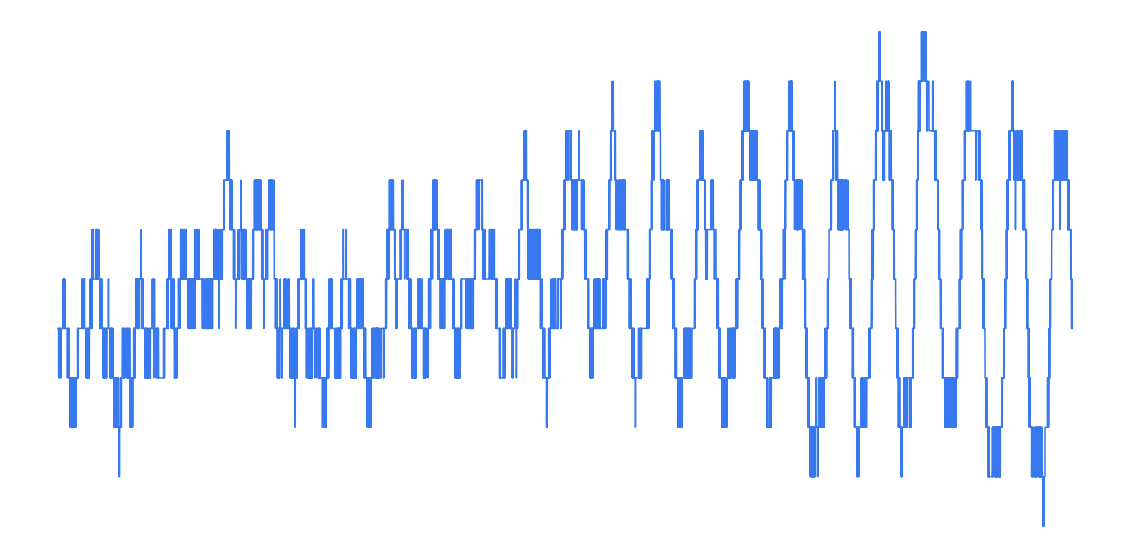

Finishing data 17453 2
Finishing data 17453
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/18177


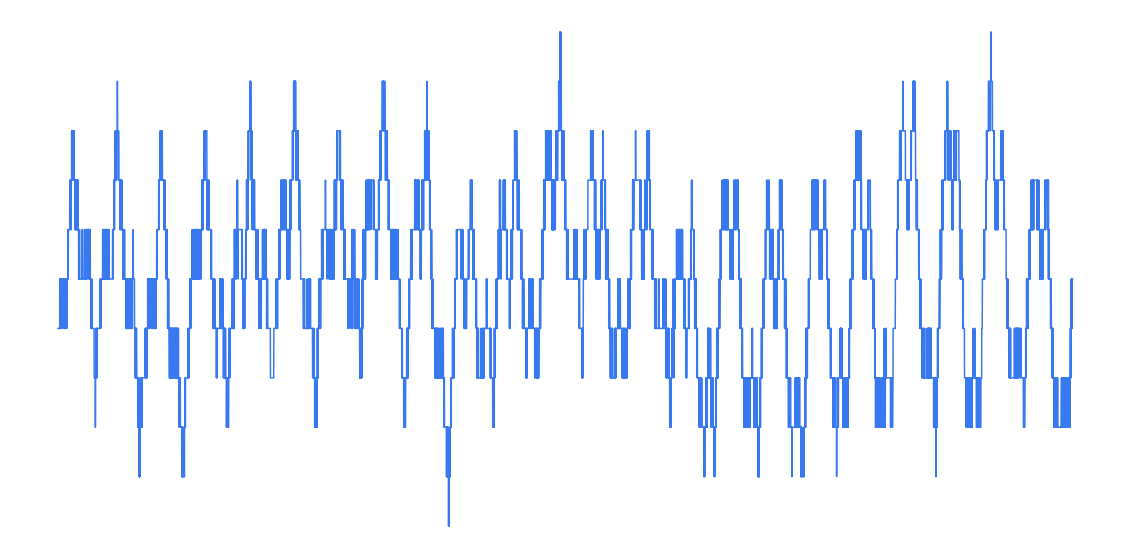

Finishing data 18177 1


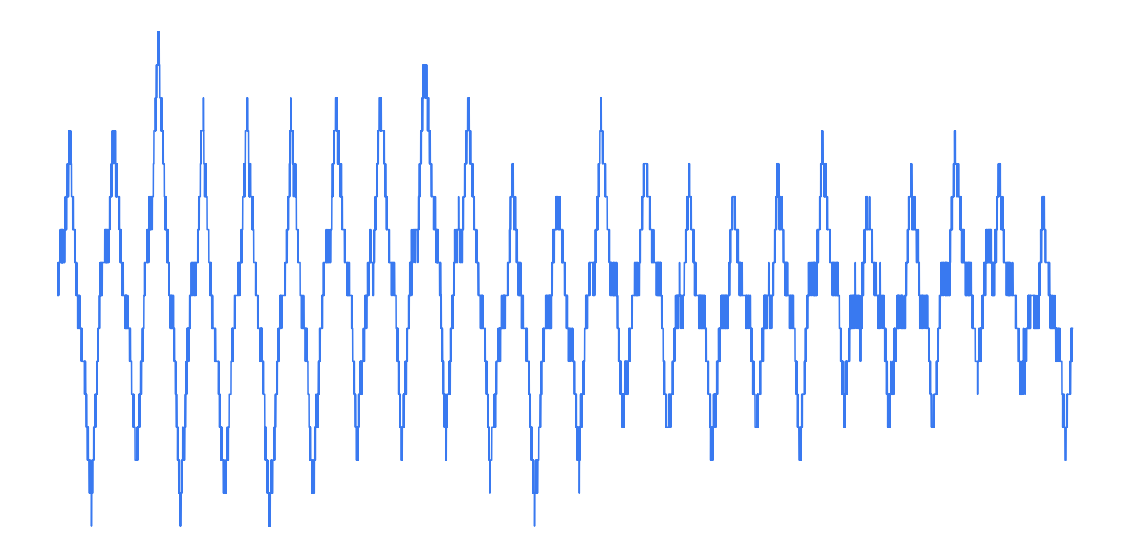

Finishing data 18177 2
Finishing data 18177
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/18184


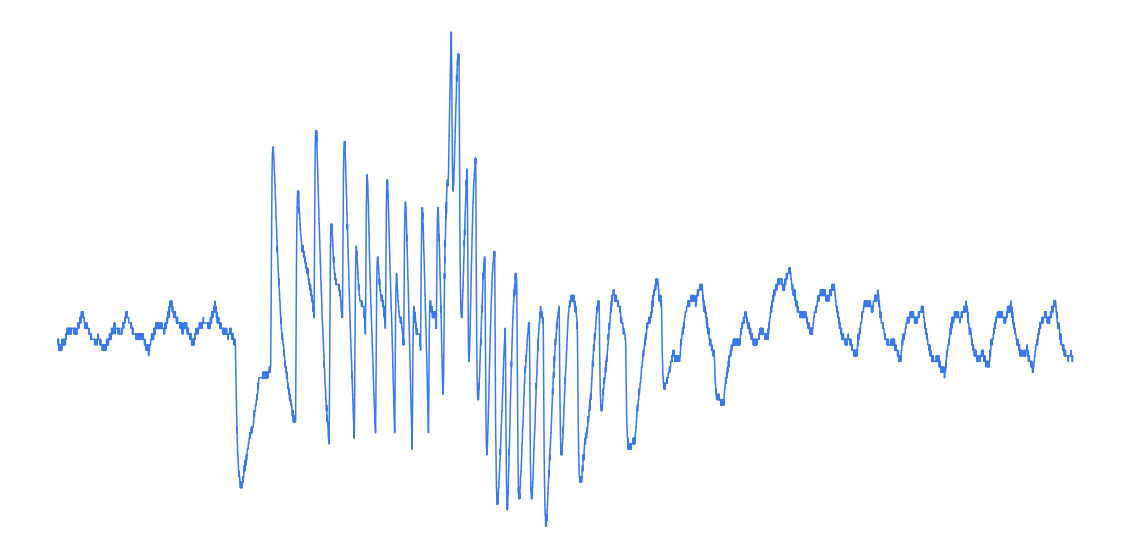

Finishing data 18184 1


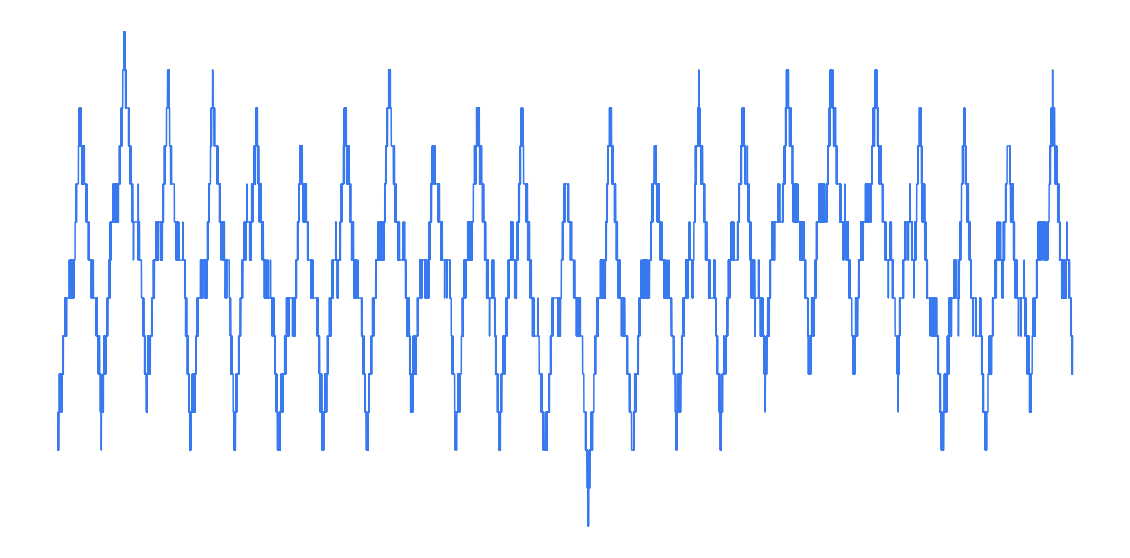

Finishing data 18184 2
Finishing data 18184
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/19088


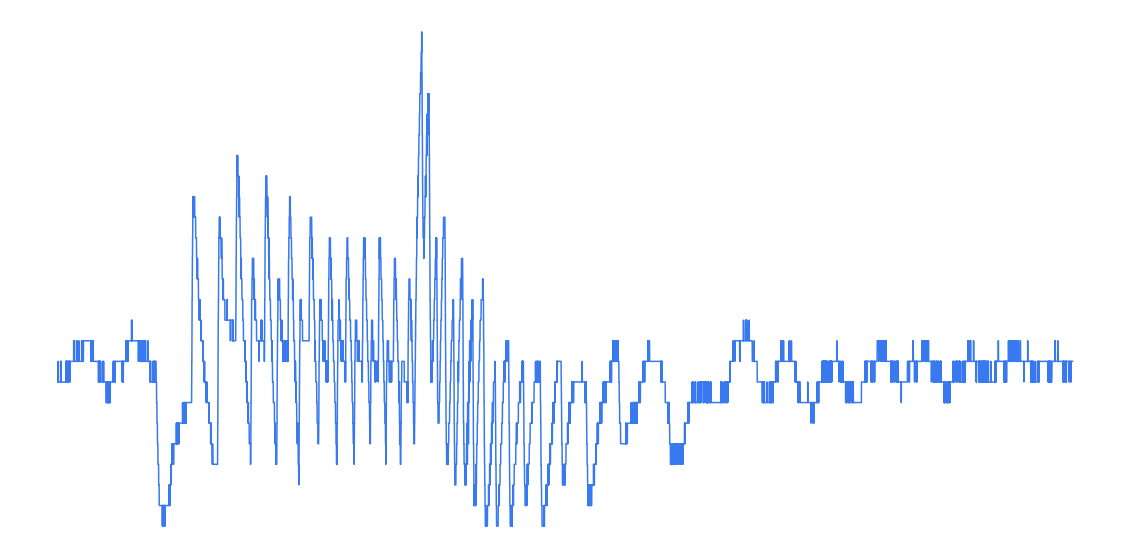

Finishing data 19088 1


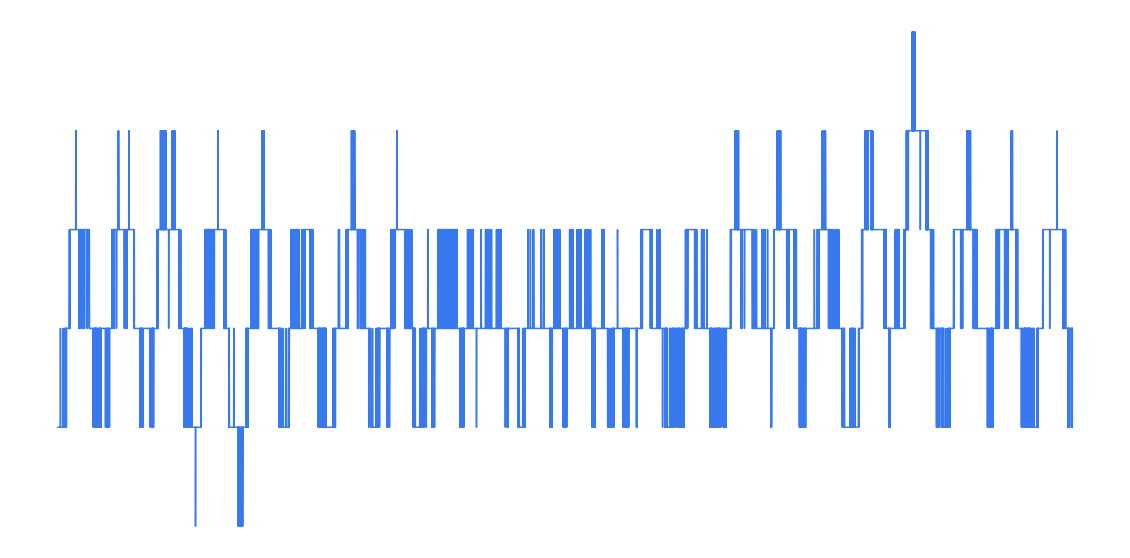

Finishing data 19088 2
Finishing data 19088
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/19090


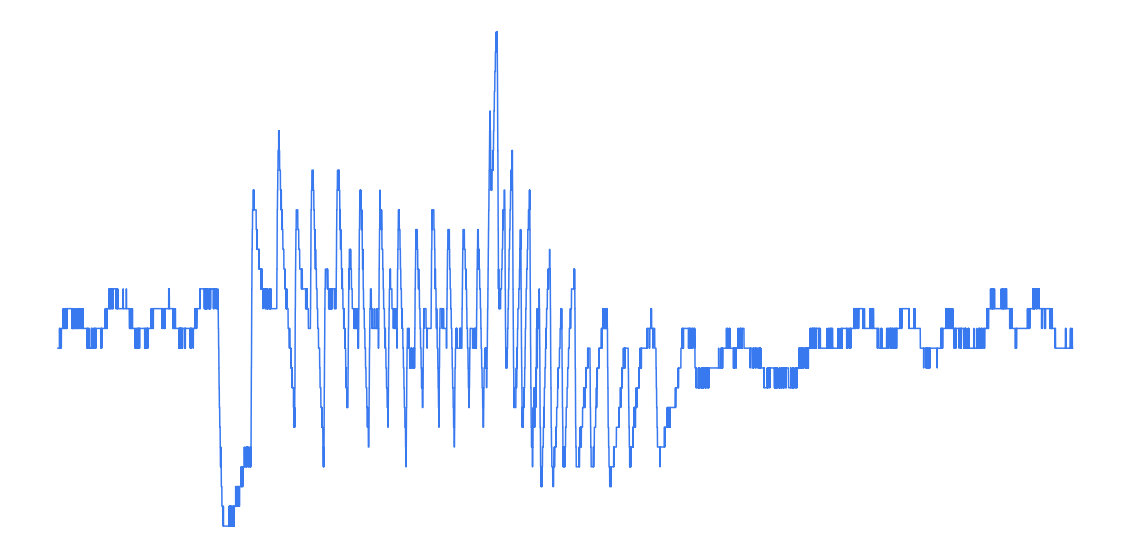

Finishing data 19090 1


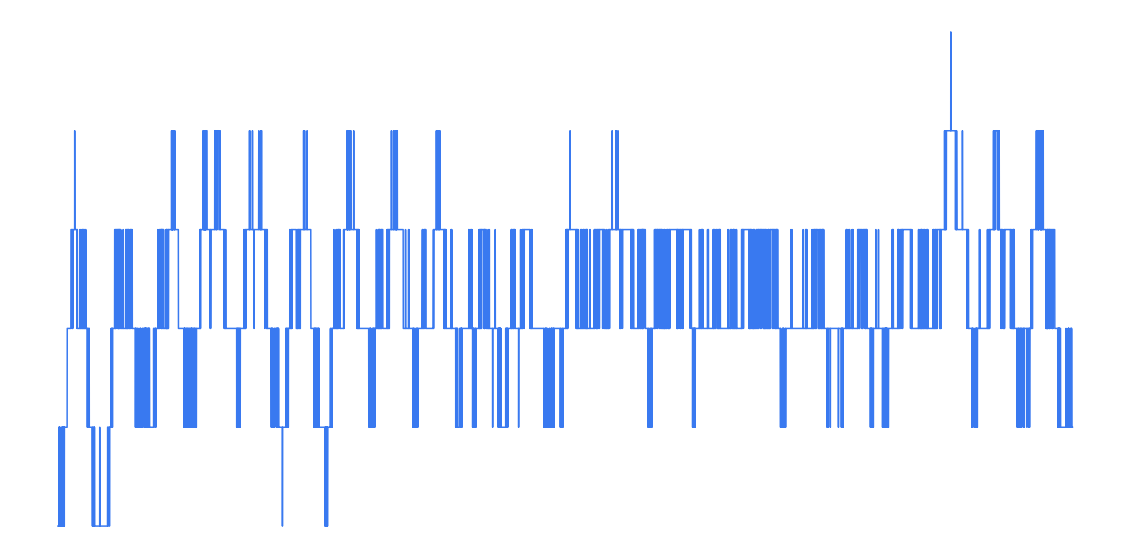

Finishing data 19090 2
Finishing data 19090
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/19093


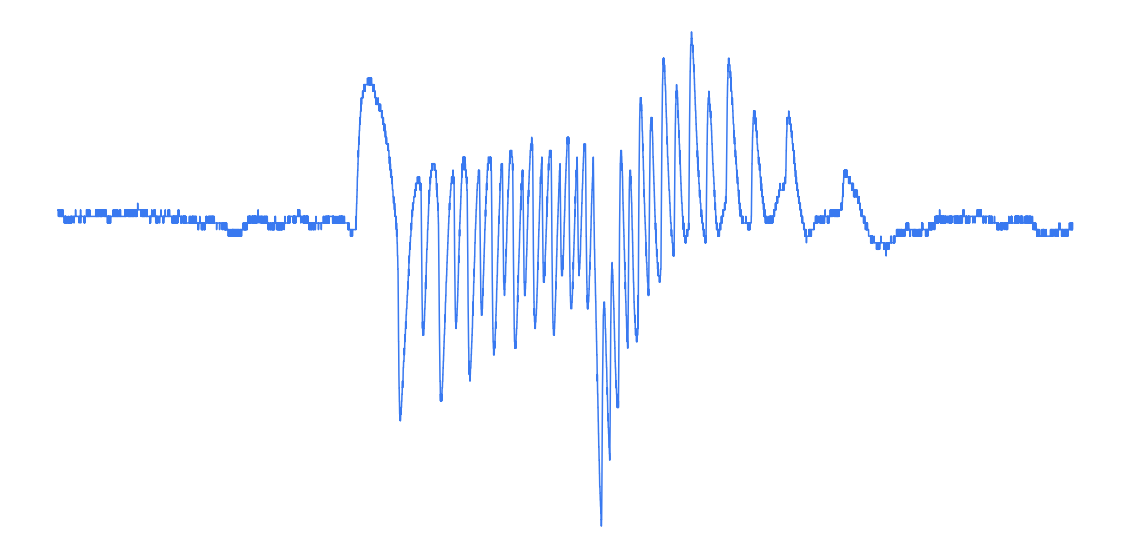

Finishing data 19093 1


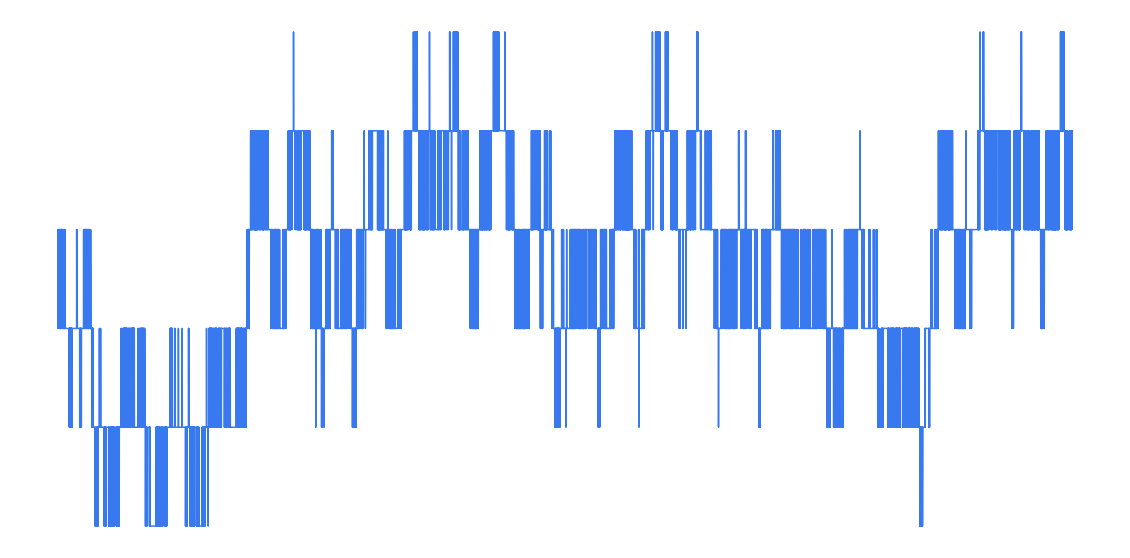

Finishing data 19093 2
Finishing data 19093
Data/mit-bih-normal-sinus-rhythm-database-1.0.0/19140


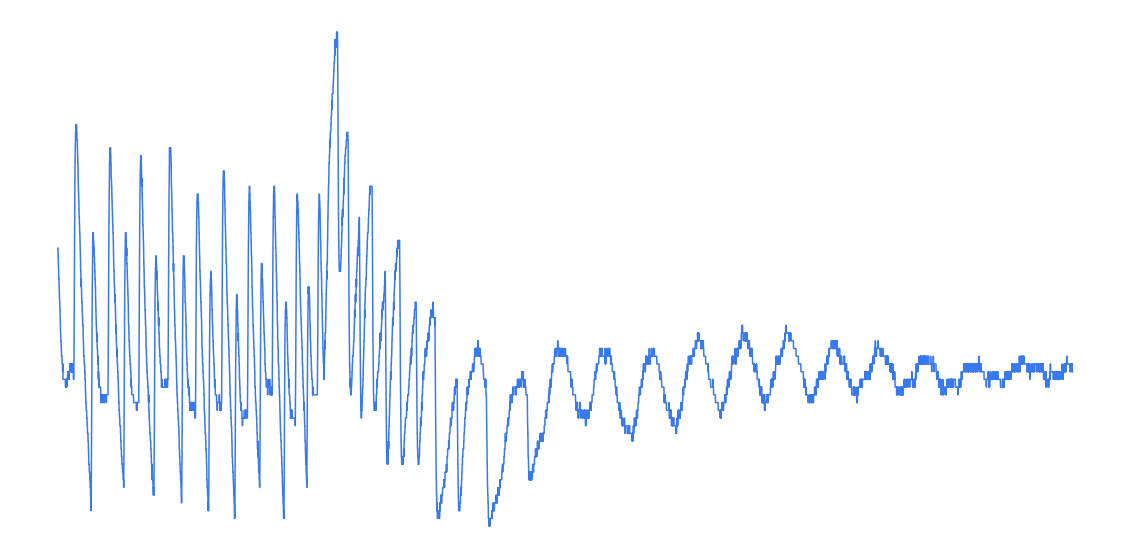

Finishing data 19140 1


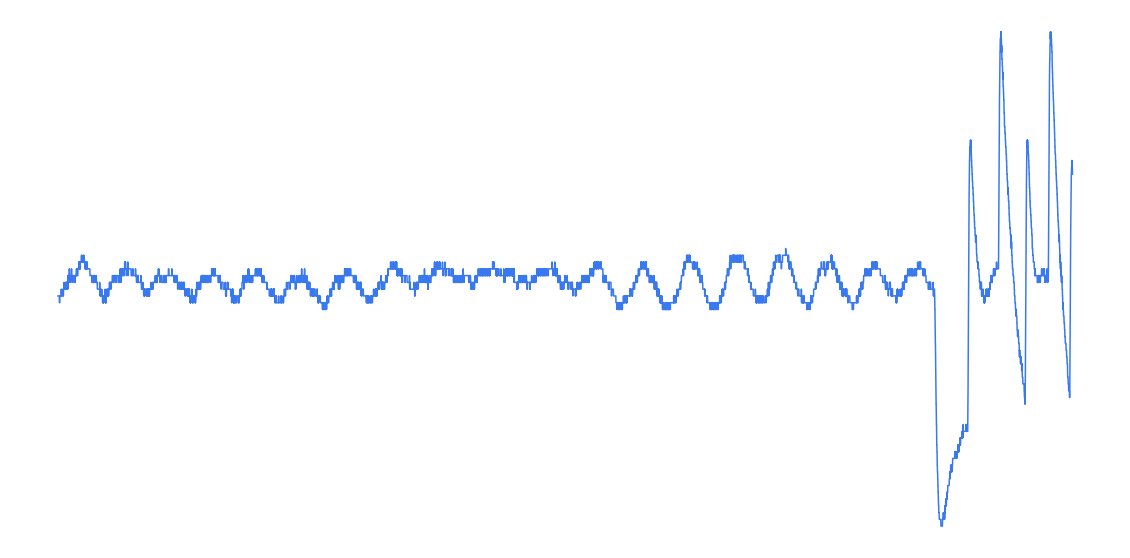

Finishing data 19140 2
Finishing data 19140


In [9]:
for v in lines:
    directory = "Data/mit-bih-normal-sinus-rhythm-database-1.0.0/"+v
    print(directory)

    # looping 2x
    for itr in range(1, 3):
        # Calculate time of start and finish 
        record = wfdb.rdrecord(directory)
        time = record.sig_len # Get length of time

        # Setup value of time frame
        m = (1000*60)/4 # times value, 30 second

        # setup time start and finish
        start = int(time-(m*itr))
        finish = int(time-(m*(itr-1)))

        saveImage(v, itr, directory, record, start, finish, 'Timeseries-Normal')
    print('Finishing data '+str(v))

### Preprocessing - Sudden Cardiac Death Dataset

In [10]:
vf_dt = pd.read_csv("Data/sudden-cardiac-death-holter-database-1.0.0/VF Data.csv", sep=';')
noVF = vf_dt[vf_dt['VF Onset Time (elapsed)'].str.contains("VF")]['Dat Files'].unique()

# remove no VF from the data
vf_dt = vf_dt[~vf_dt['Dat Files'].isin(noVF)]

for i in range(0,len(noVF)):
    noVF[i] = noVF[i].replace(".dat", "")

noVF

array(['40', '42', '49'], dtype=object)

In [11]:
# Read all of the record on SCD dataset
lines = []
with open('Data/sudden-cardiac-death-holter-database-1.0.0/RECORDS') as f:
    lines = f.readlines()

for ii in range(0,len(lines)):
    lines[ii] = lines[ii][:-1]
    
# Remove No VF data
for x in noVF:
    lines.remove(x)

lines

['30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '41',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '50',
 '51',
 '52']

In [12]:
vf_dt = vf_dt.reset_index(drop=True)

# check the VF time of data
vf_dt

,Dat Files,Hea Files,Unaudited Annotations,Audited Annotations,Signal Duration,VF Onset Time (elapsed)
0,30.dat,30.hea,30.ari,30.atr,24.33.17,07.54.33
1,31.dat,31.hea,31.ari,31.atr,13.58.40,13.42.24
2,32.dat,32.hea,32.ari,32.atr,24.20.00,16.45.18
3,33.dat,33.hea,33.ari,NaN,24.33.00,04.46.19
4,34.dat,34.hea,34.ari,34.atr,07.05.20,06.35.44
5,35.dat,35.hea,35.ari,35.atr,24.52.00,24.34.56
6,36.dat,36.hea,36.ari,36.atr,20.21.20,18.59.01
7,37.dat,37.hea,37.ari,NaN,25.08.00,01.31.13
8,38.dat,38.hea,38.ari,NaN,18.18.25,08.01.54
9,39.dat,39.hea,39.ari,NaN,05.47.00,04.37.51


Data/sudden-cardiac-death-holter-database-1.0.0/30


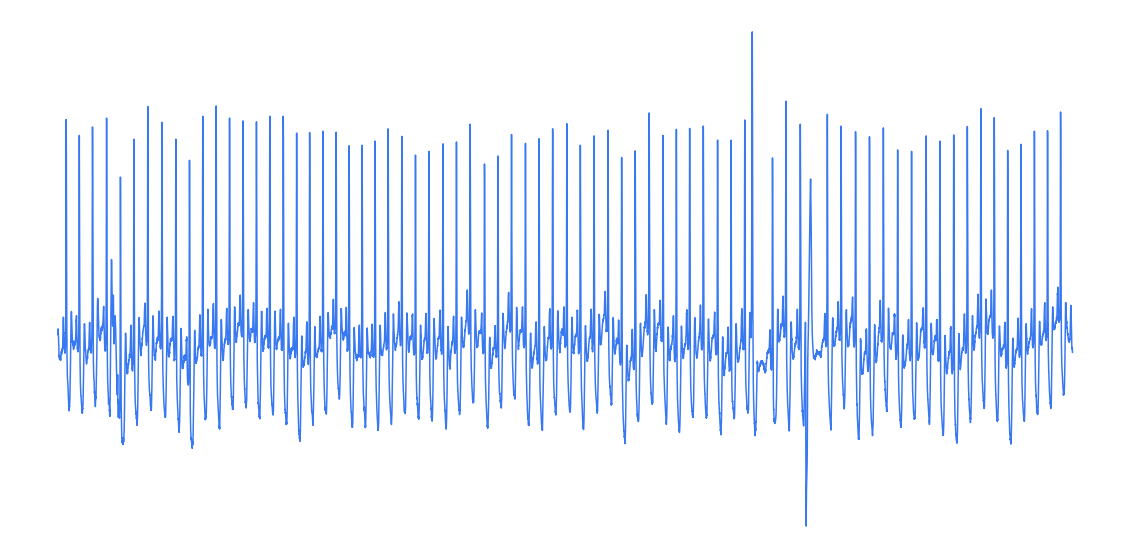

Finishing data 30 1


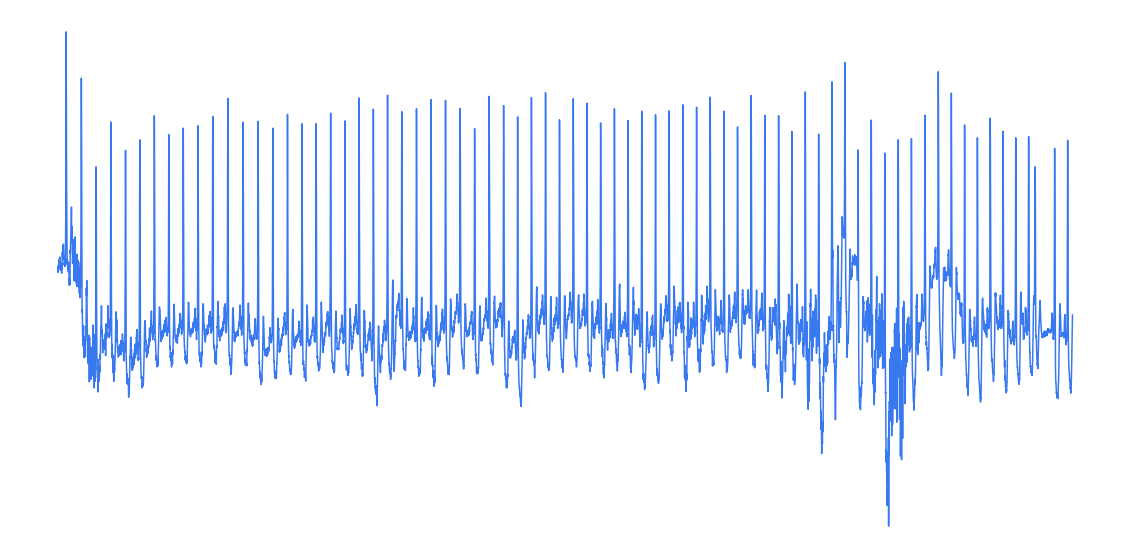

Finishing data 30 2
Finishing data 30
Data/sudden-cardiac-death-holter-database-1.0.0/31


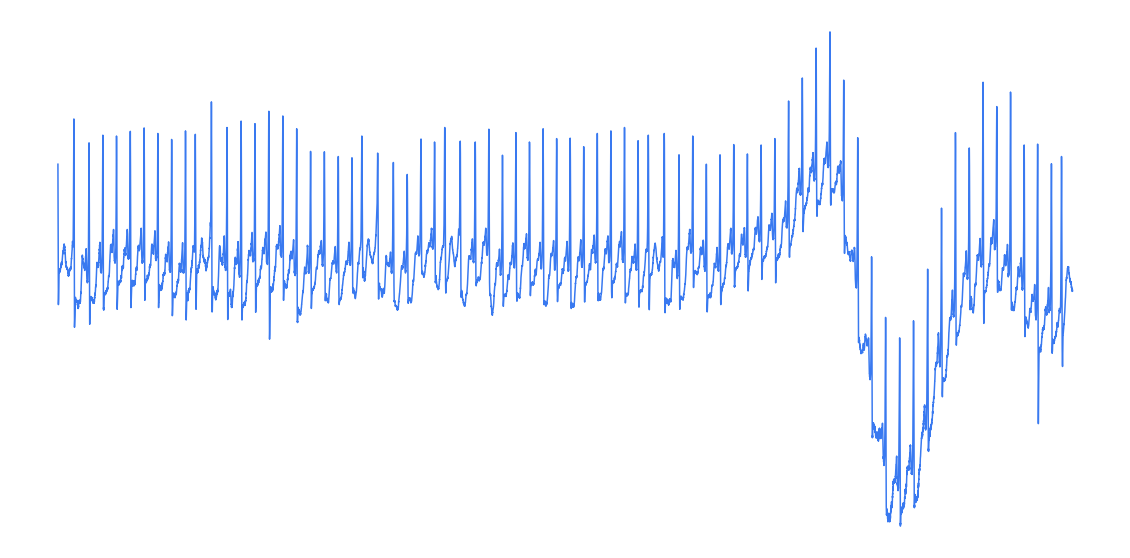

Finishing data 31 1


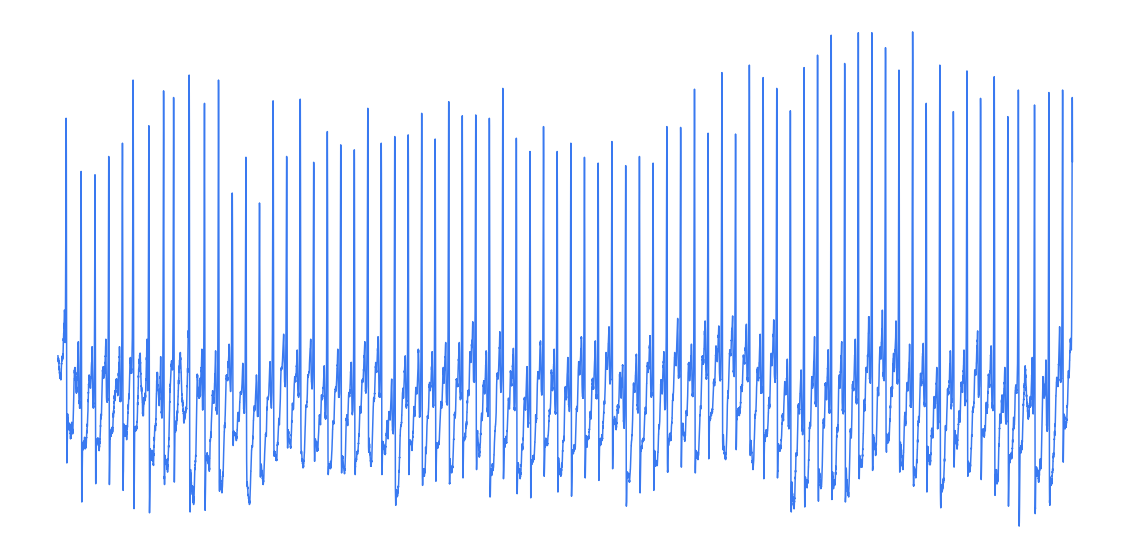

Finishing data 31 2
Finishing data 31
Data/sudden-cardiac-death-holter-database-1.0.0/32


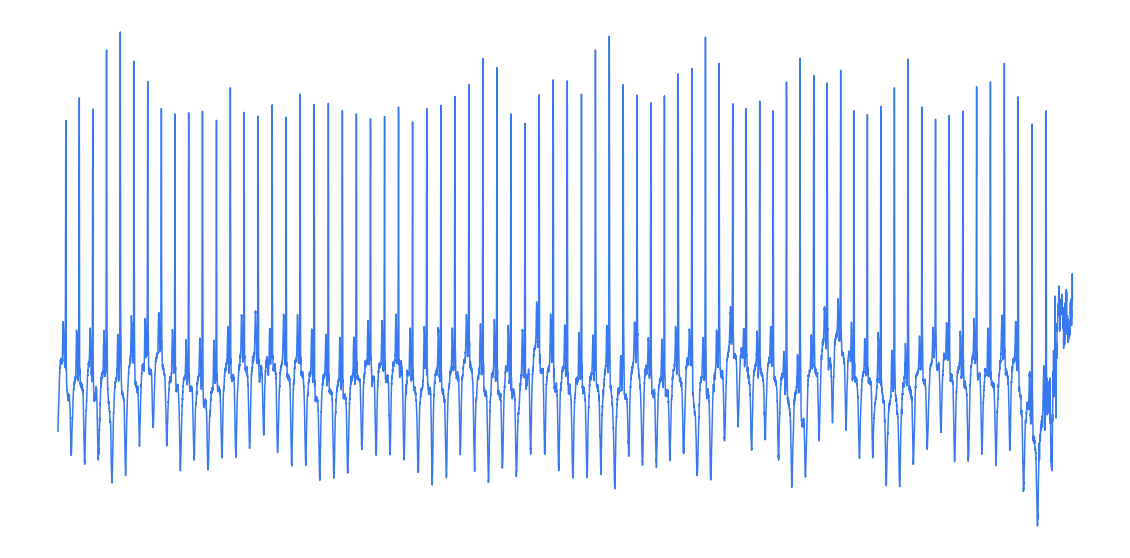

Finishing data 32 1


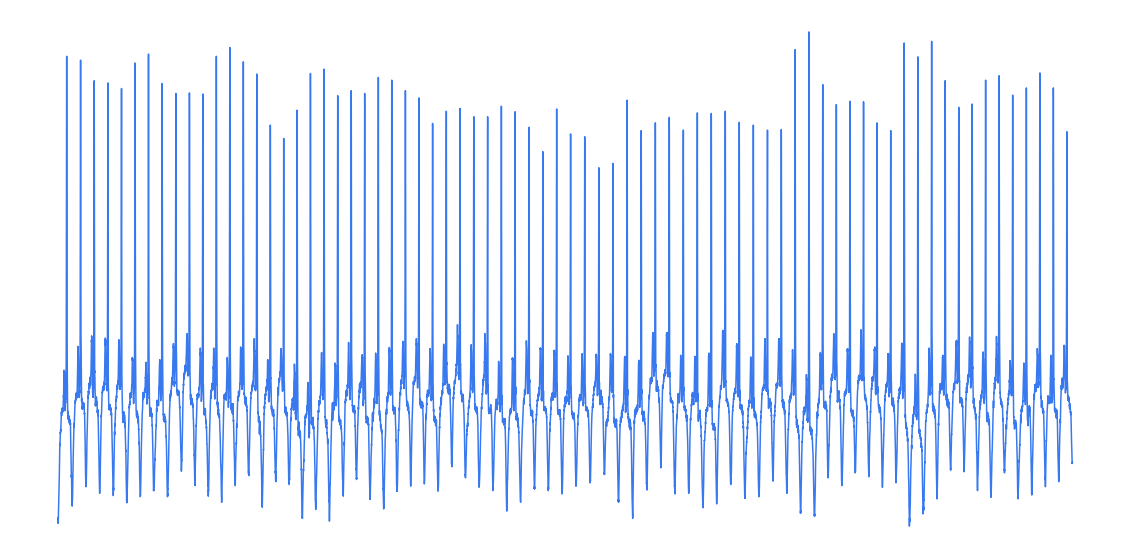

Finishing data 32 2
Finishing data 32
Data/sudden-cardiac-death-holter-database-1.0.0/33


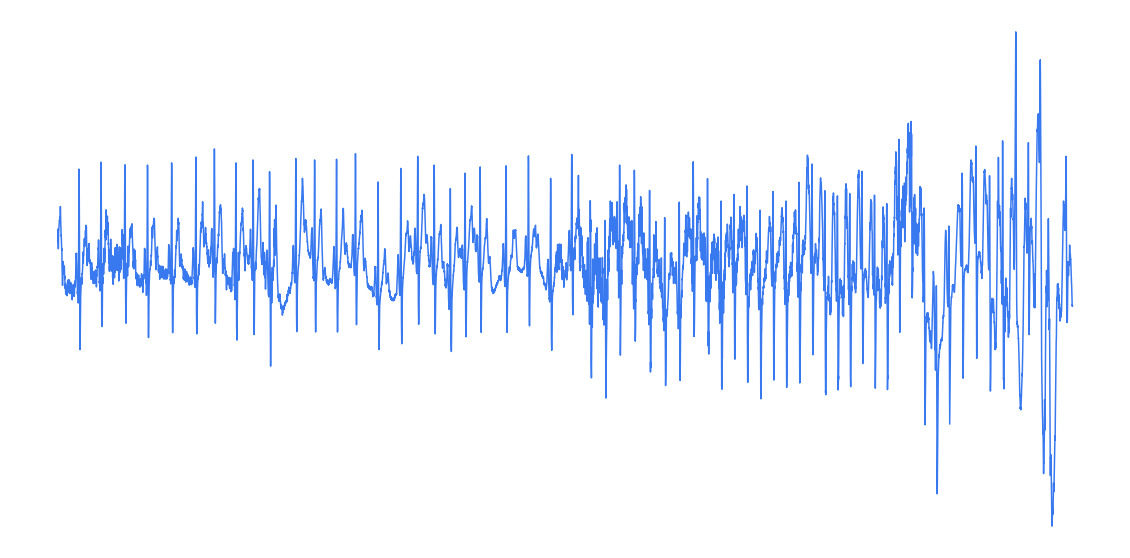

Finishing data 33 1


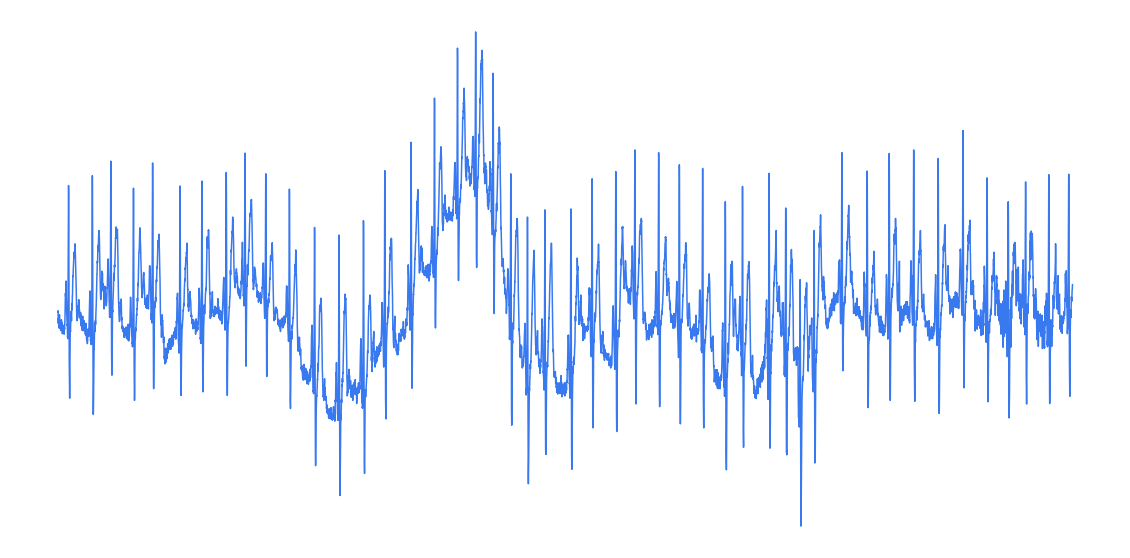

Finishing data 33 2
Finishing data 33
Data/sudden-cardiac-death-holter-database-1.0.0/34


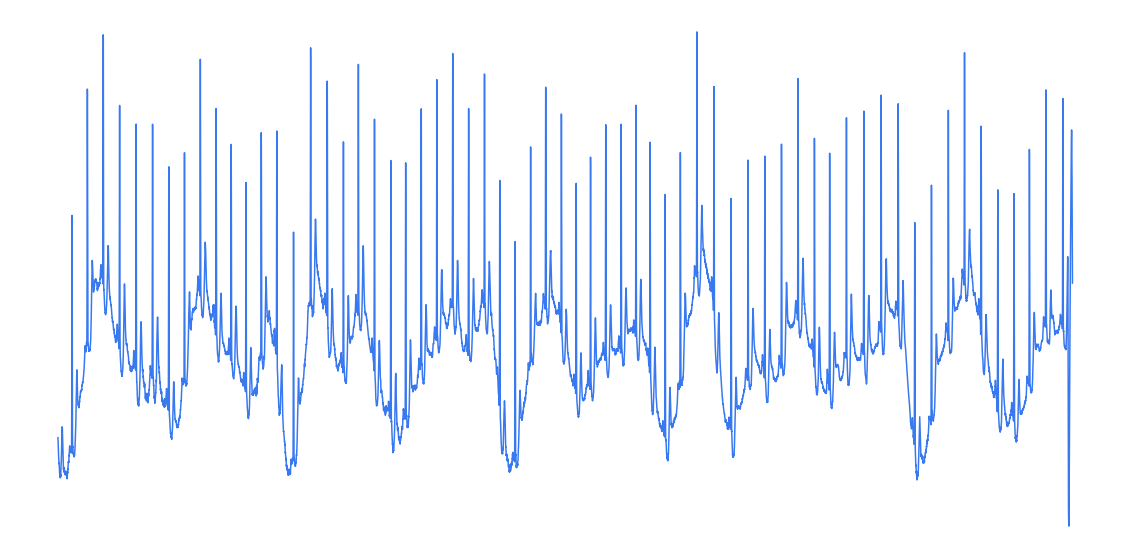

Finishing data 34 1


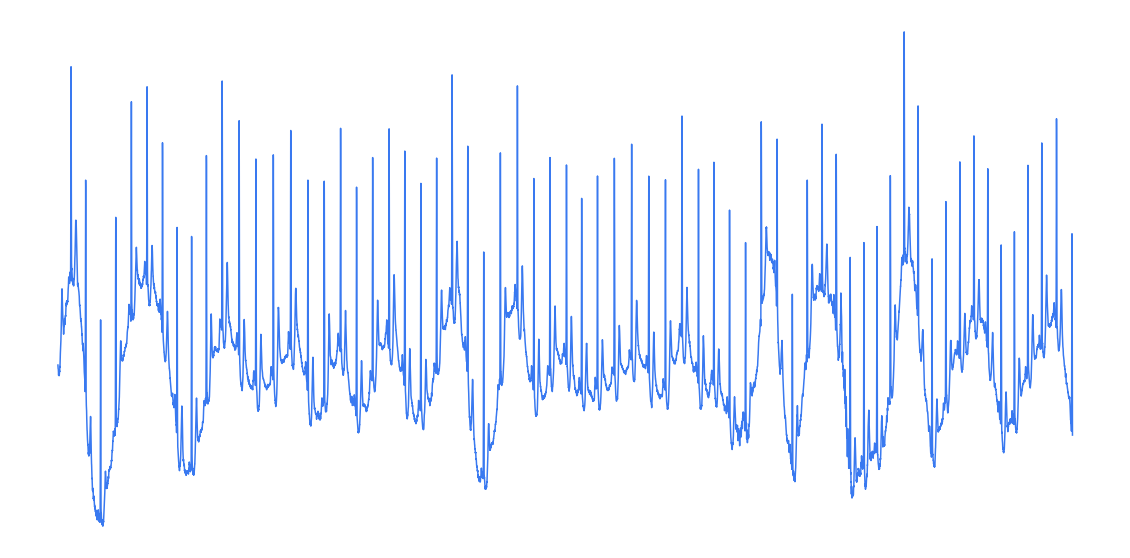

Finishing data 34 2
Finishing data 34
Data/sudden-cardiac-death-holter-database-1.0.0/35


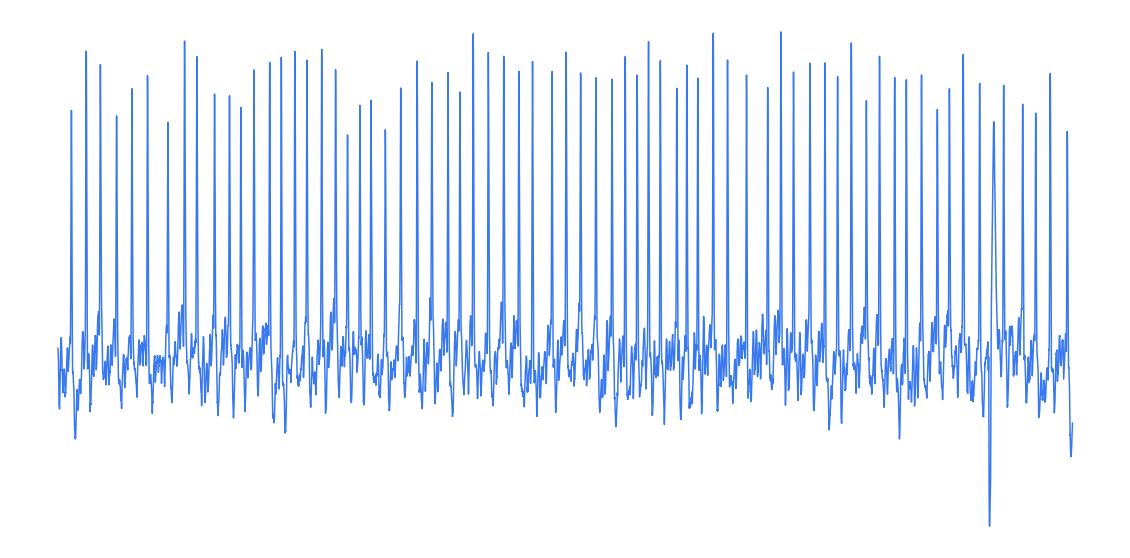

Finishing data 35 1


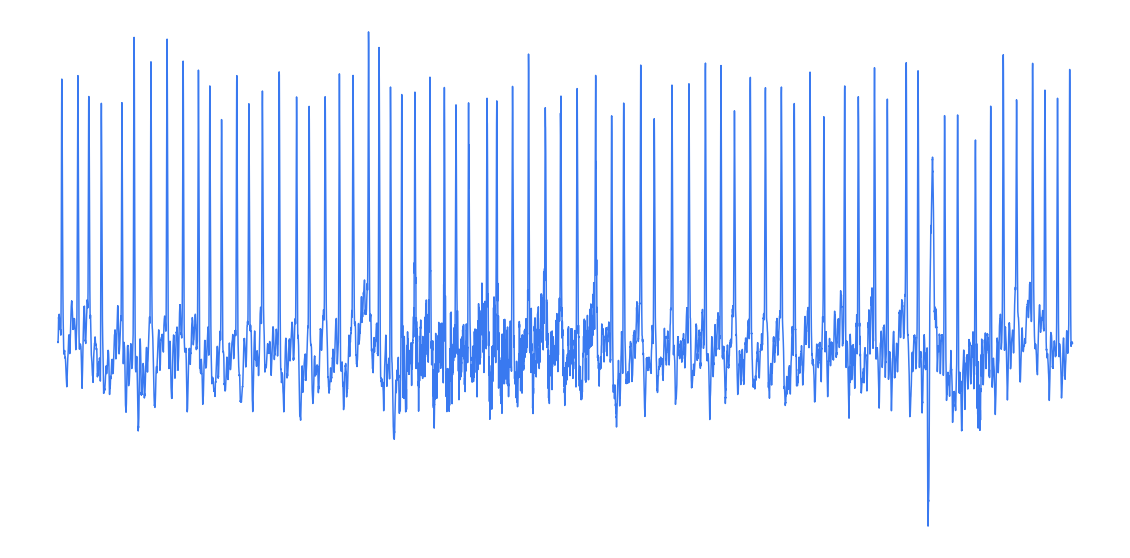

Finishing data 35 2
Finishing data 35
Data/sudden-cardiac-death-holter-database-1.0.0/36


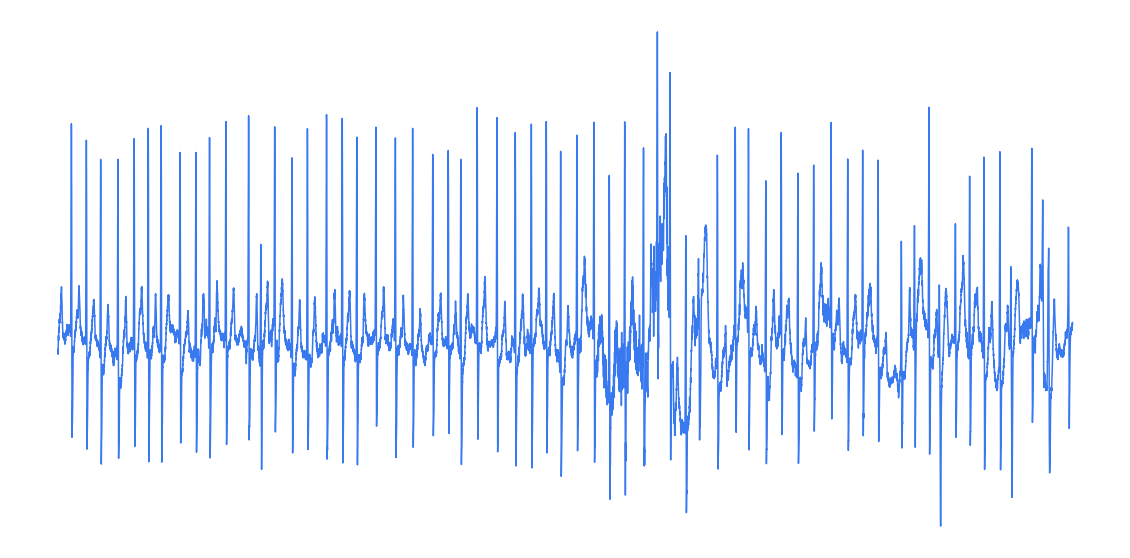

Finishing data 36 1


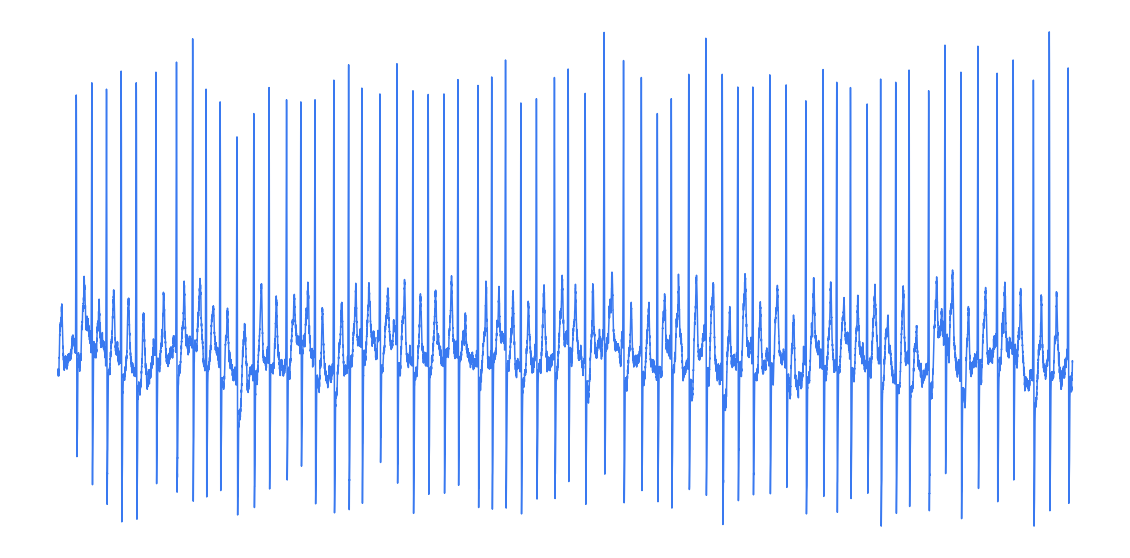

Finishing data 36 2
Finishing data 36
Data/sudden-cardiac-death-holter-database-1.0.0/37


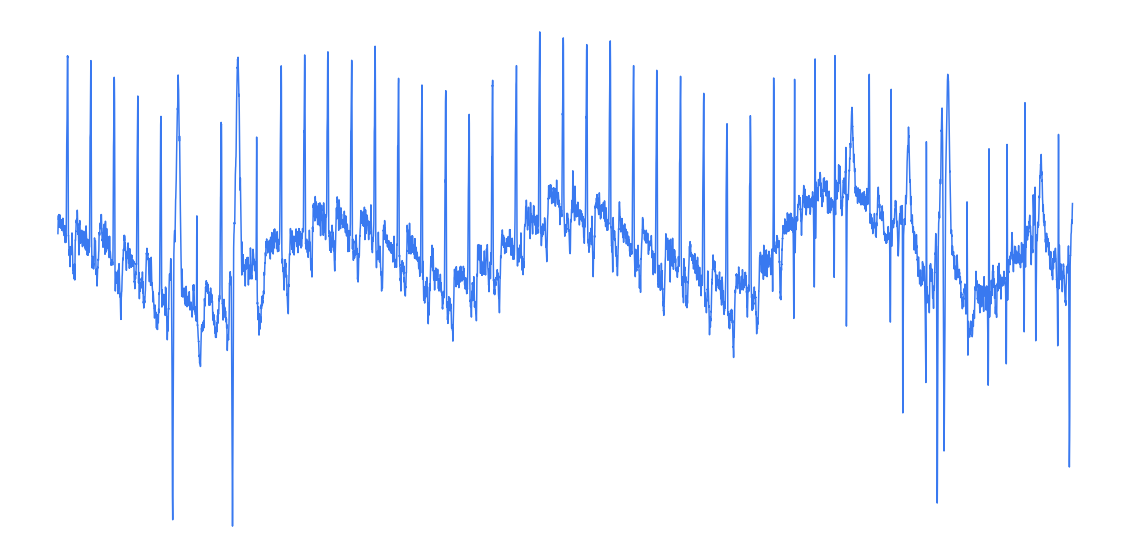

Finishing data 37 1


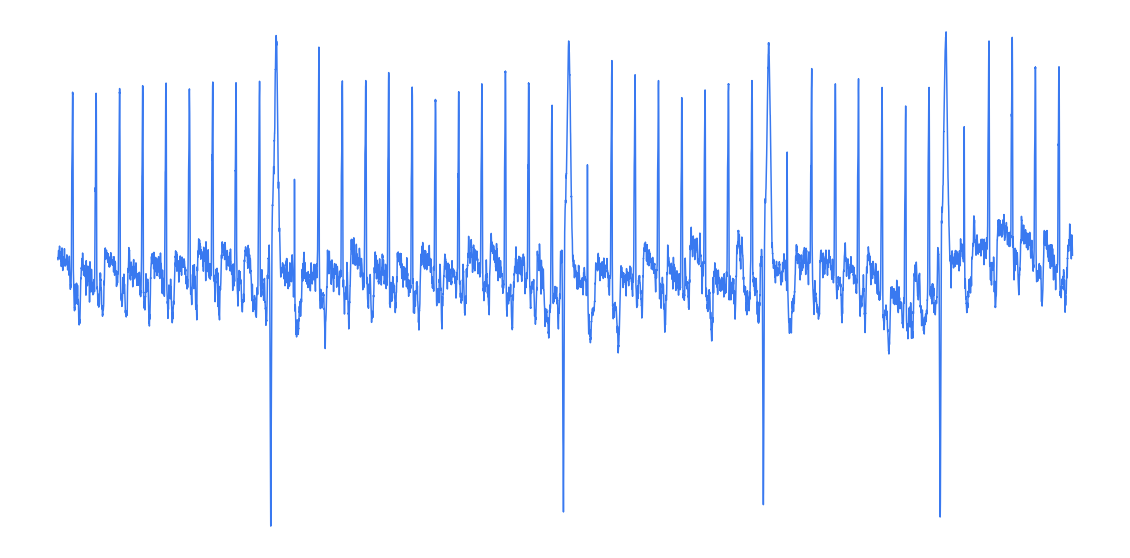

Finishing data 37 2
Finishing data 37
Data/sudden-cardiac-death-holter-database-1.0.0/38


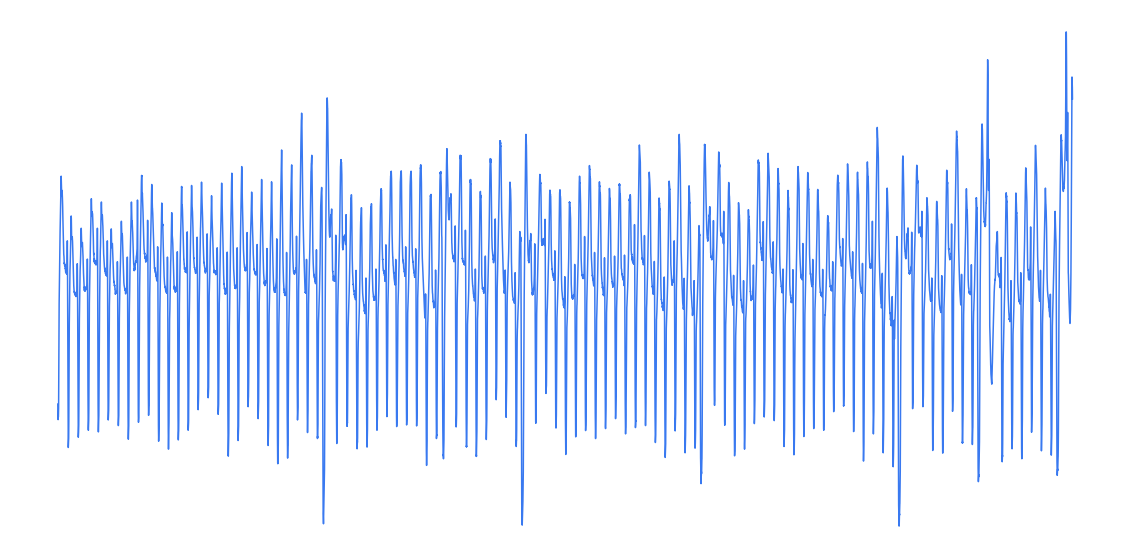

Finishing data 38 1


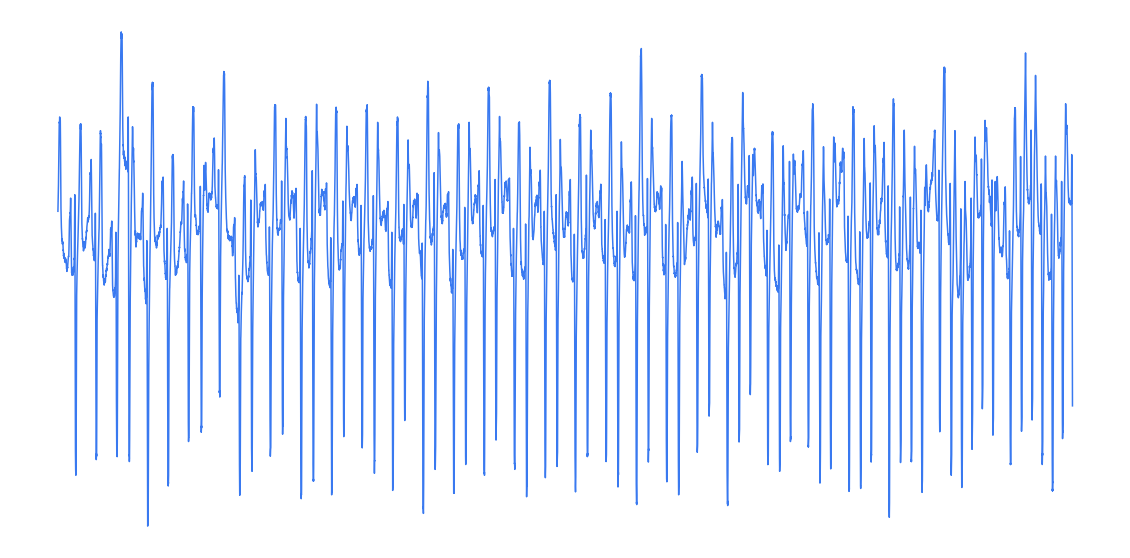

Finishing data 38 2
Finishing data 38
Data/sudden-cardiac-death-holter-database-1.0.0/39


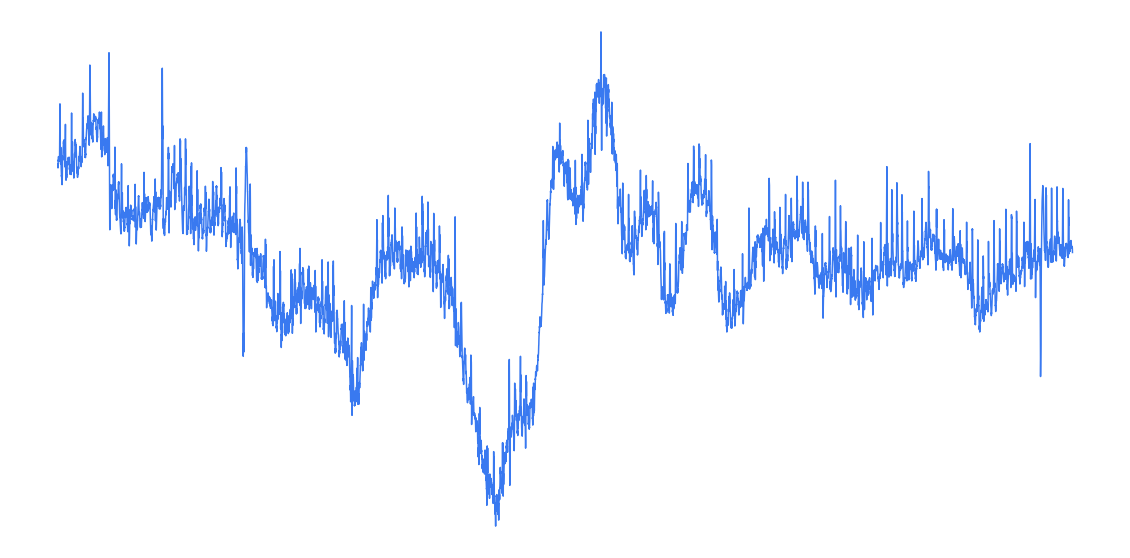

Finishing data 39 1


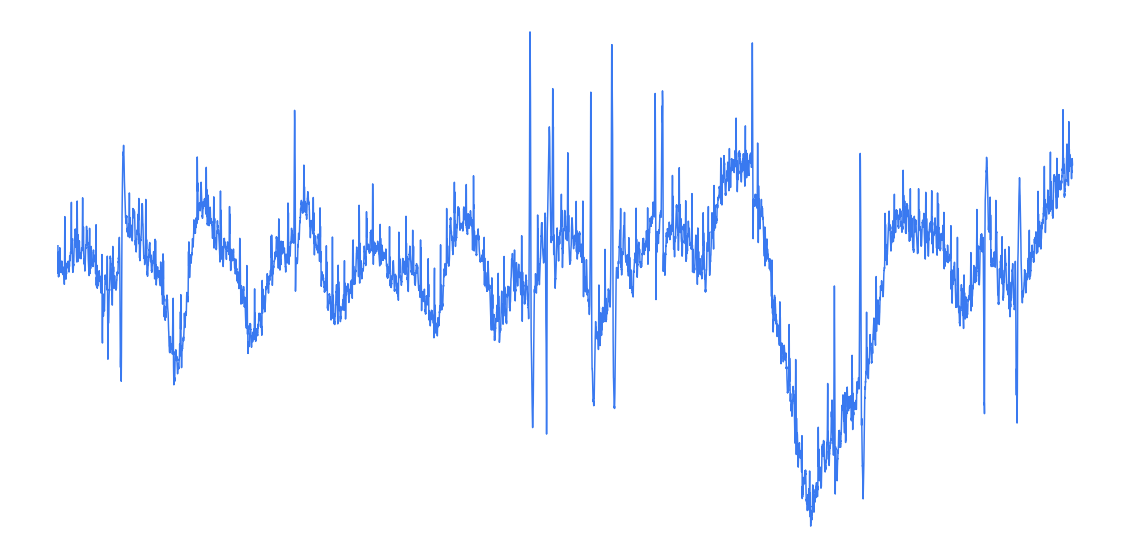

Finishing data 39 2
Finishing data 39
Data/sudden-cardiac-death-holter-database-1.0.0/41


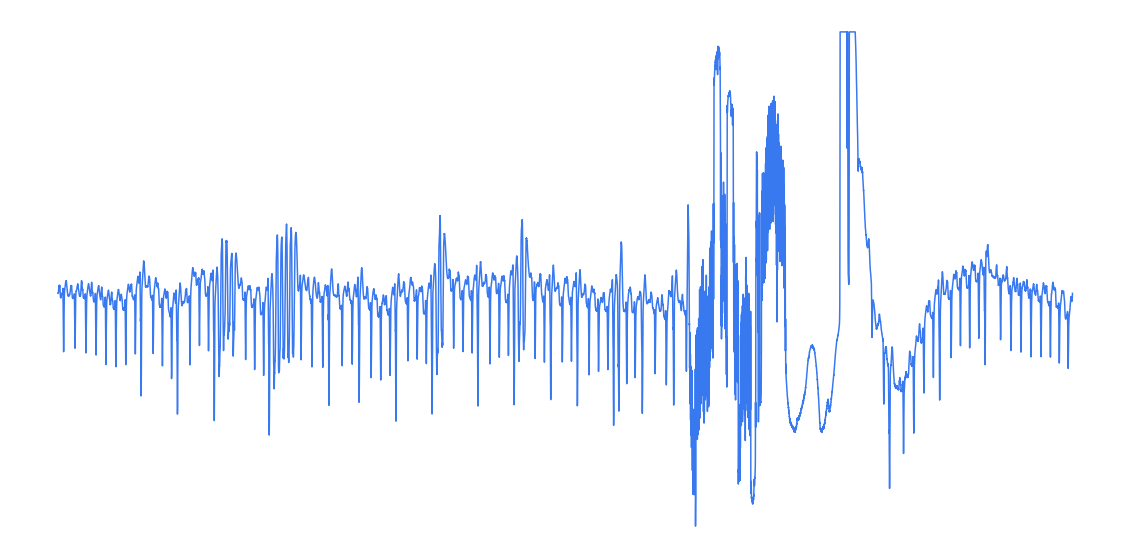

Finishing data 41 1


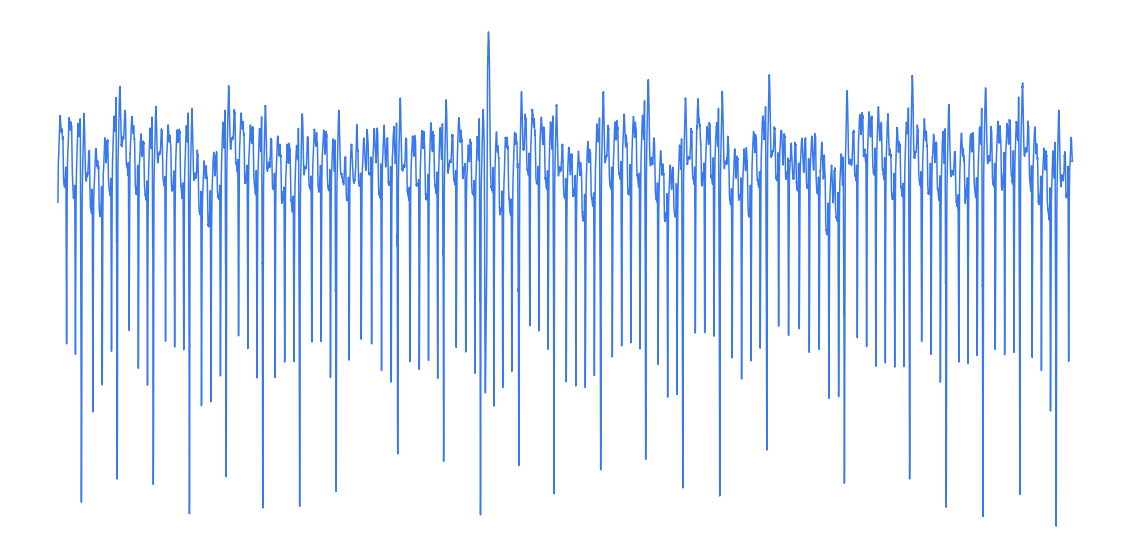

Finishing data 41 2
Finishing data 41
Data/sudden-cardiac-death-holter-database-1.0.0/43


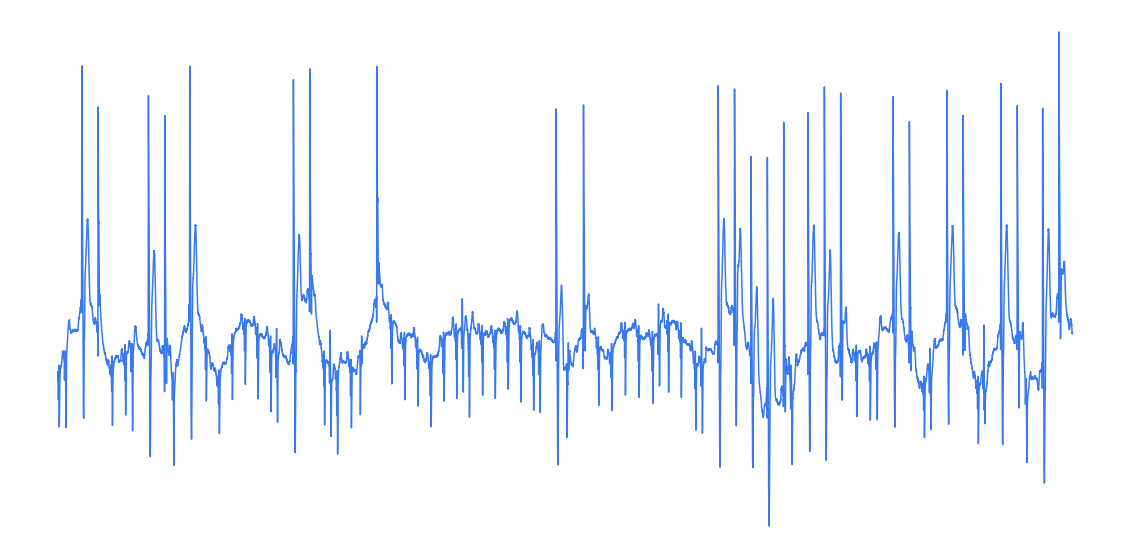

Finishing data 43 1


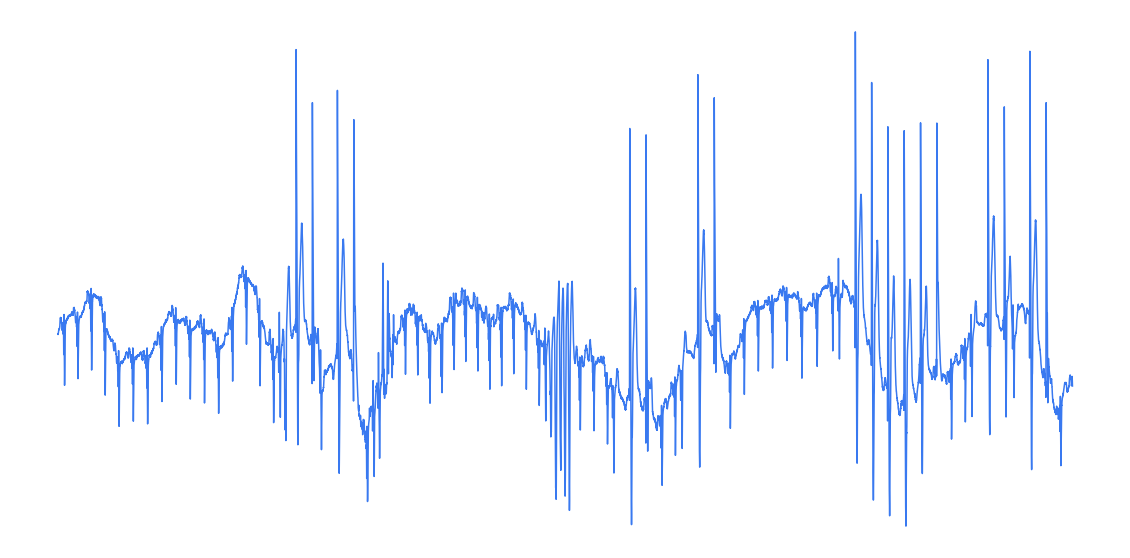

Finishing data 43 2
Finishing data 43
Data/sudden-cardiac-death-holter-database-1.0.0/44


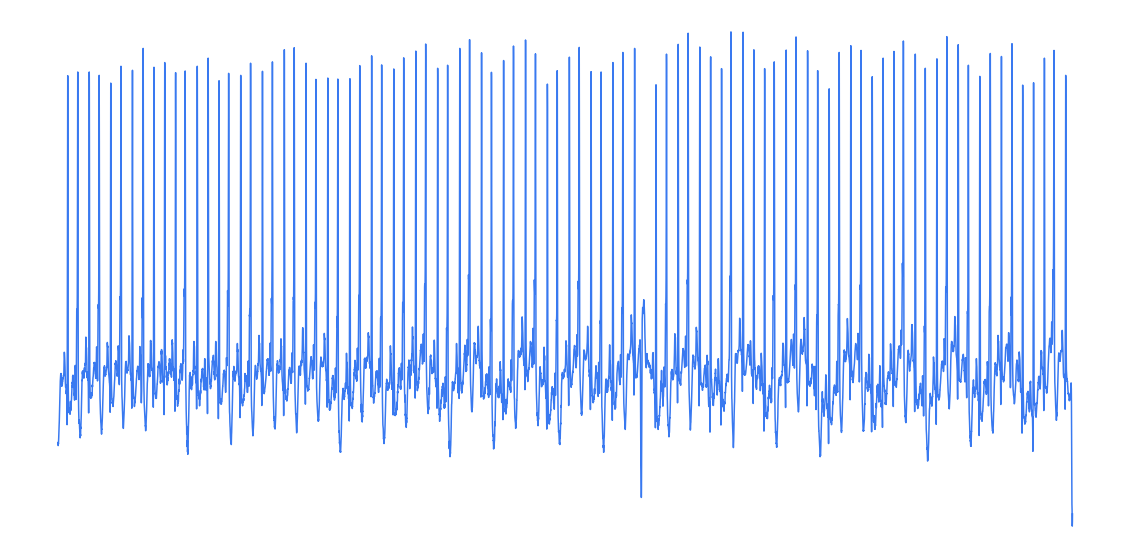

Finishing data 44 1


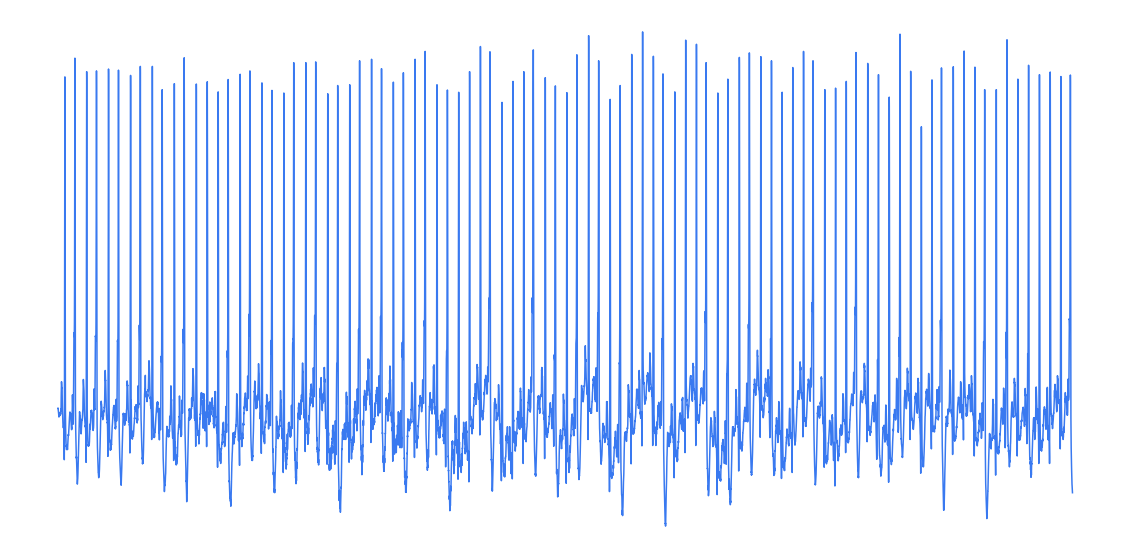

Finishing data 44 2
Finishing data 44
Data/sudden-cardiac-death-holter-database-1.0.0/45


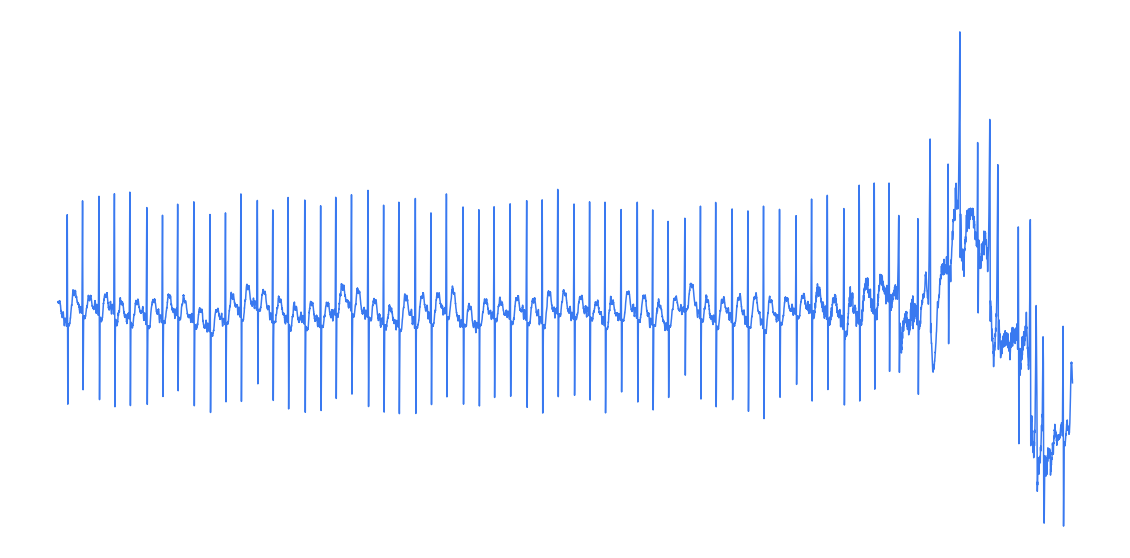

Finishing data 45 1


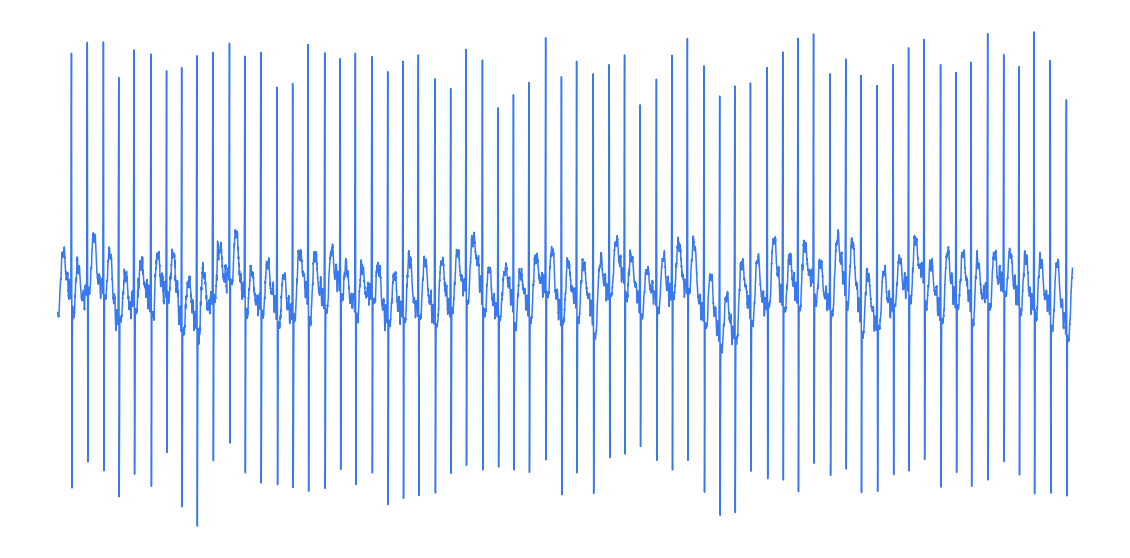

Finishing data 45 2
Finishing data 45
Data/sudden-cardiac-death-holter-database-1.0.0/46


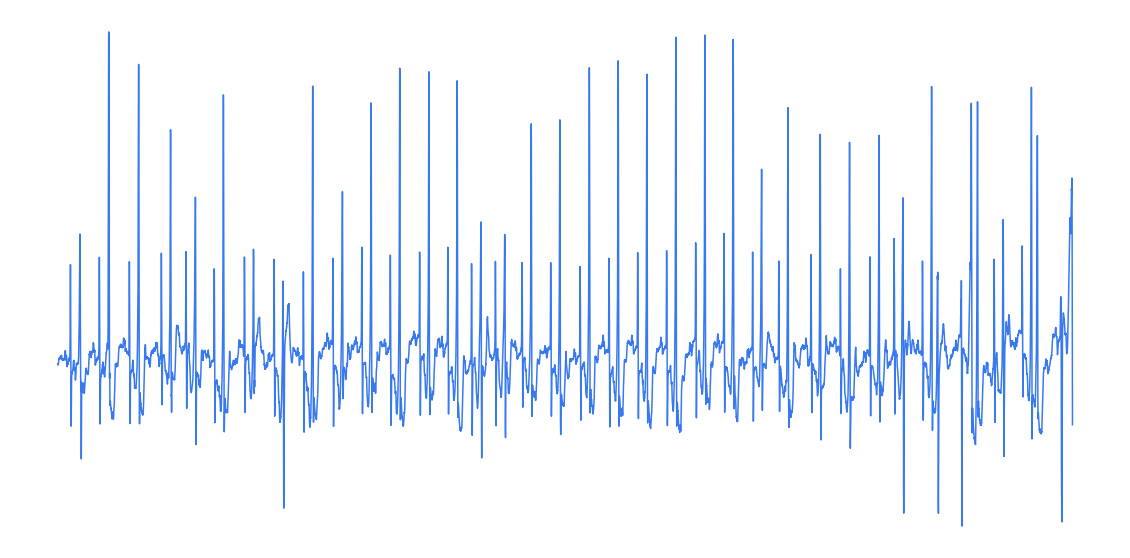

Finishing data 46 1


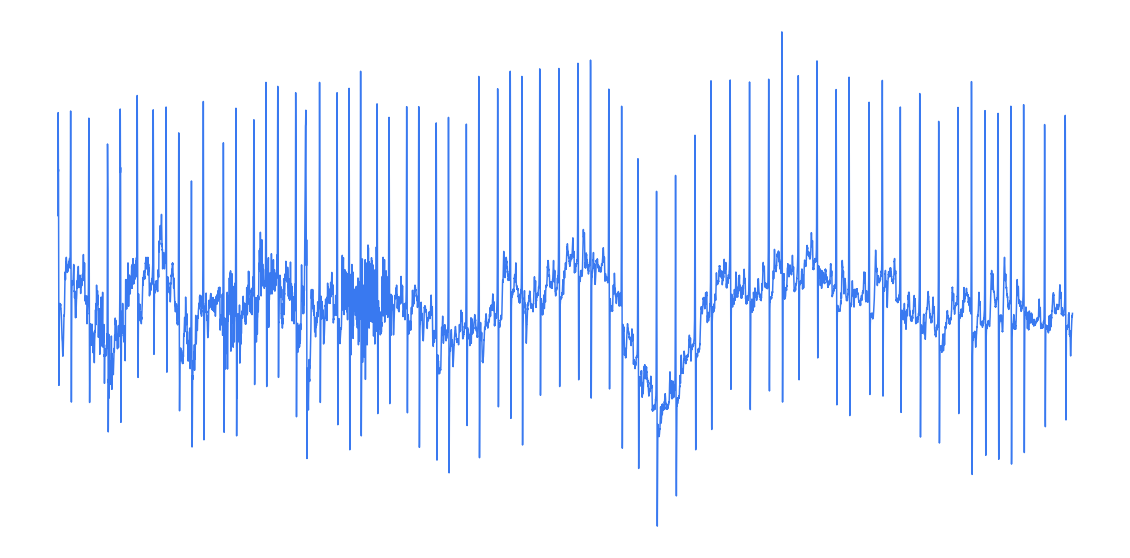

Finishing data 46 2
Finishing data 46
Data/sudden-cardiac-death-holter-database-1.0.0/47


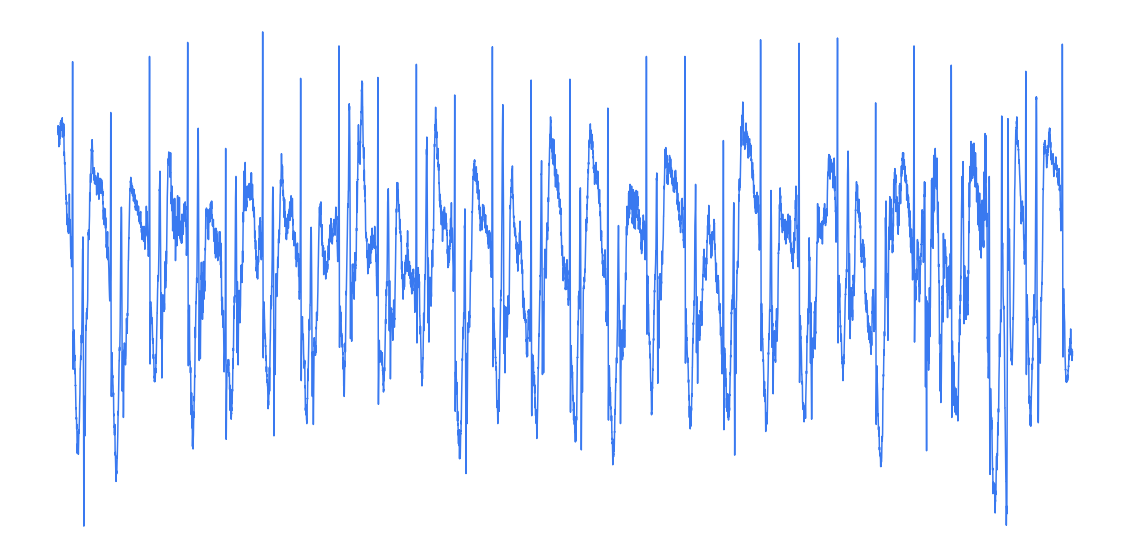

Finishing data 47 1


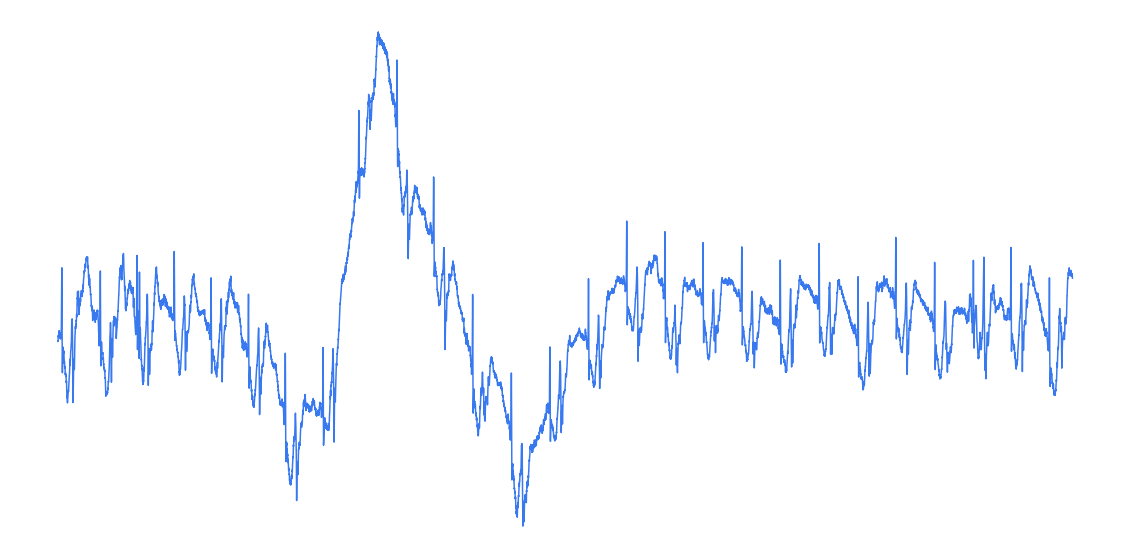

Finishing data 47 2
Finishing data 47
Data/sudden-cardiac-death-holter-database-1.0.0/48


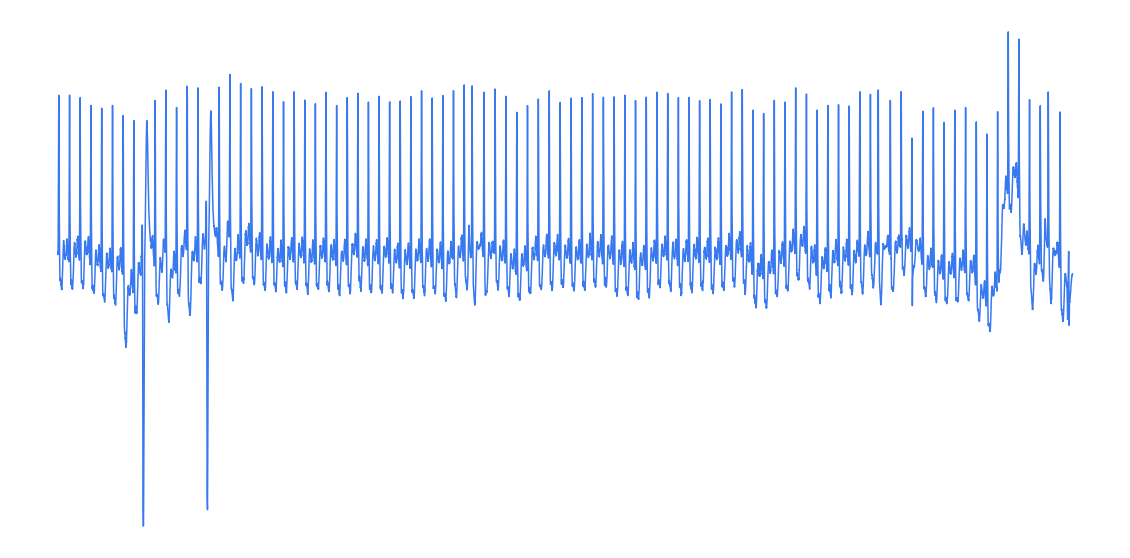

Finishing data 48 1


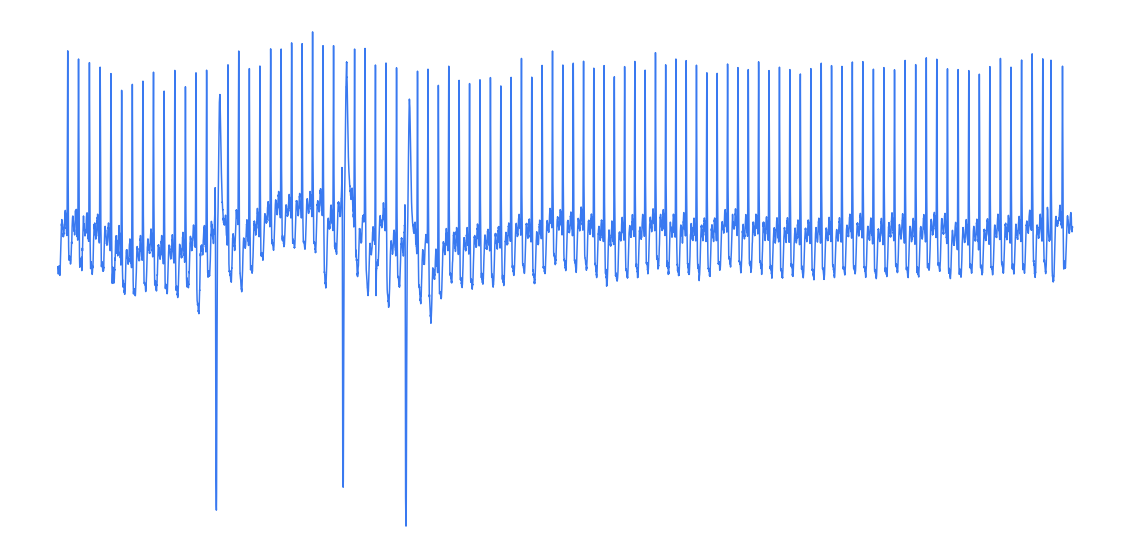

Finishing data 48 2
Finishing data 48
Data/sudden-cardiac-death-holter-database-1.0.0/50


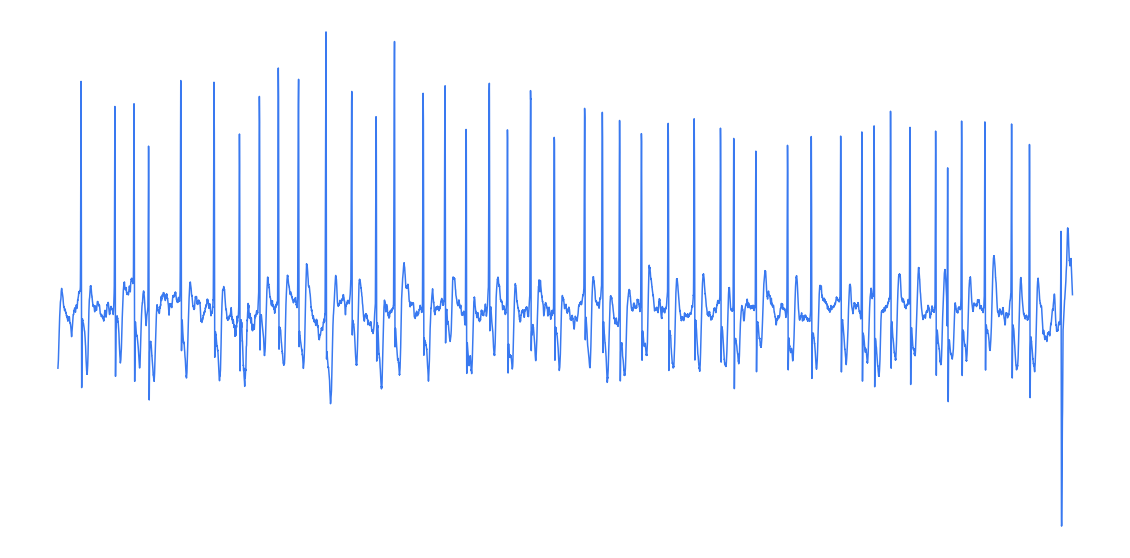

Finishing data 50 1


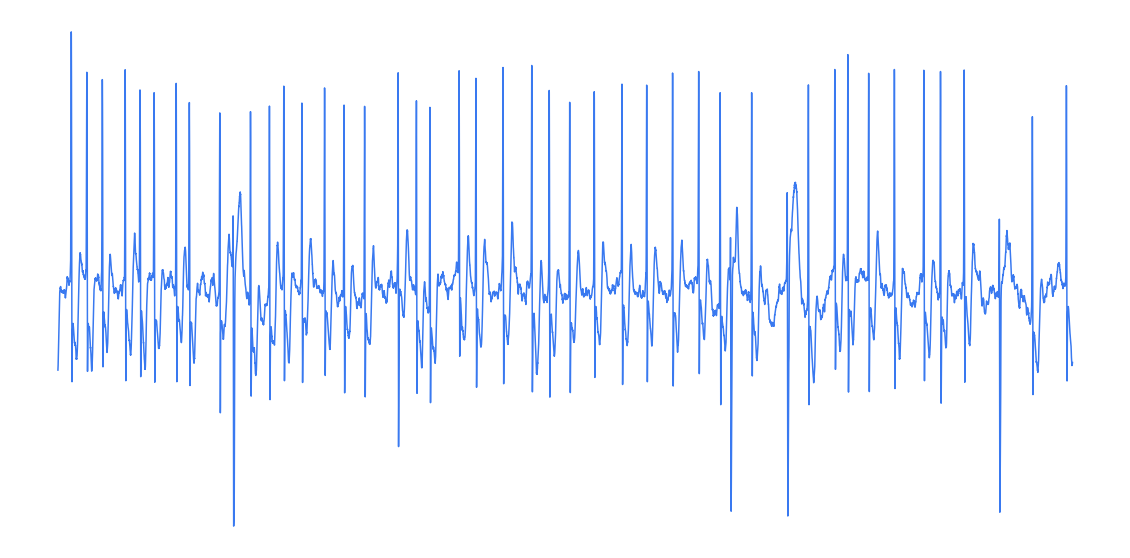

Finishing data 50 2
Finishing data 50
Data/sudden-cardiac-death-holter-database-1.0.0/51


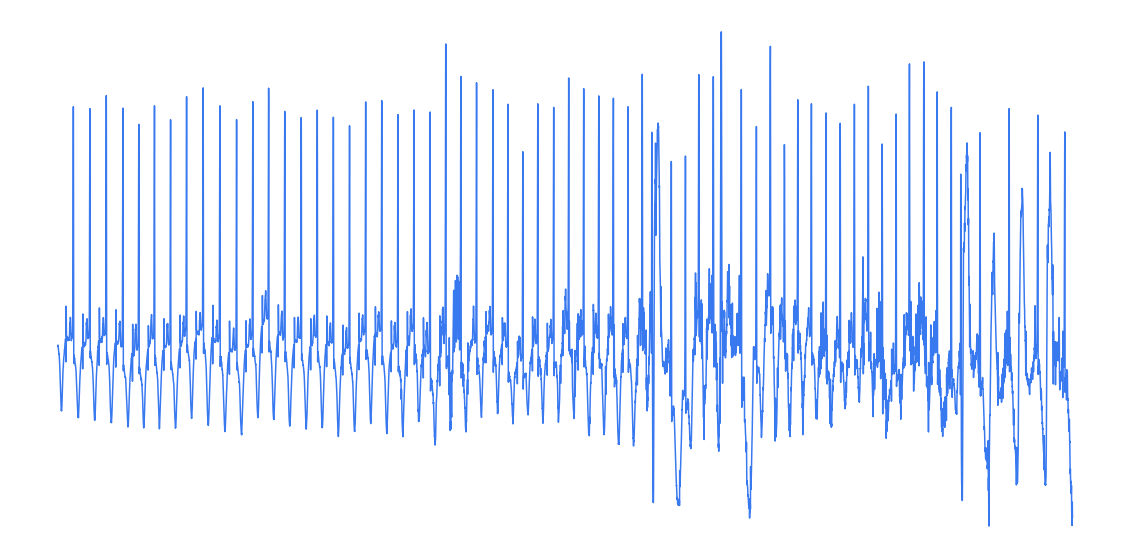

Finishing data 51 1


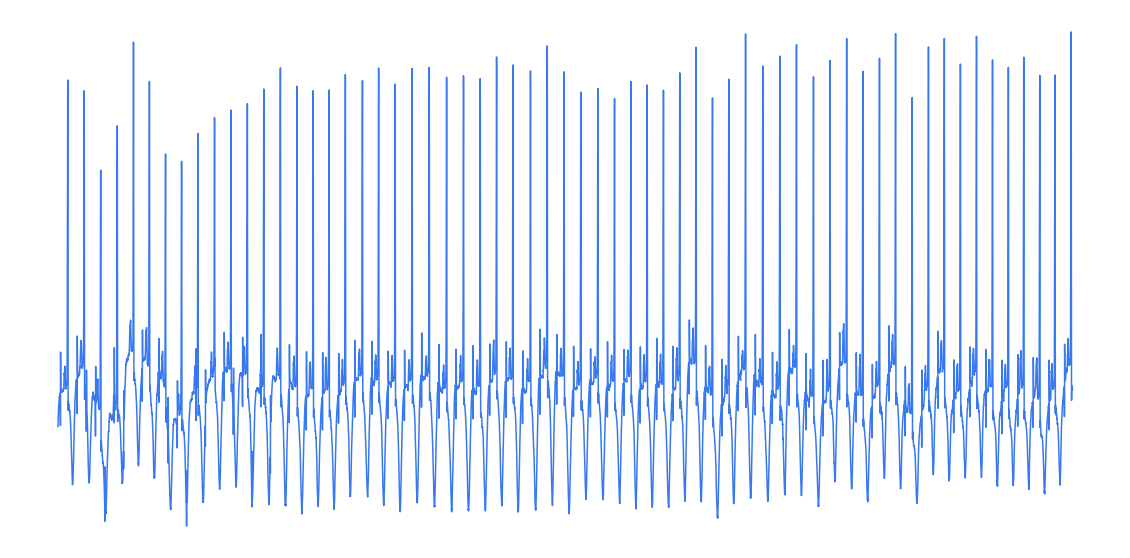

Finishing data 51 2
Finishing data 51
Data/sudden-cardiac-death-holter-database-1.0.0/52


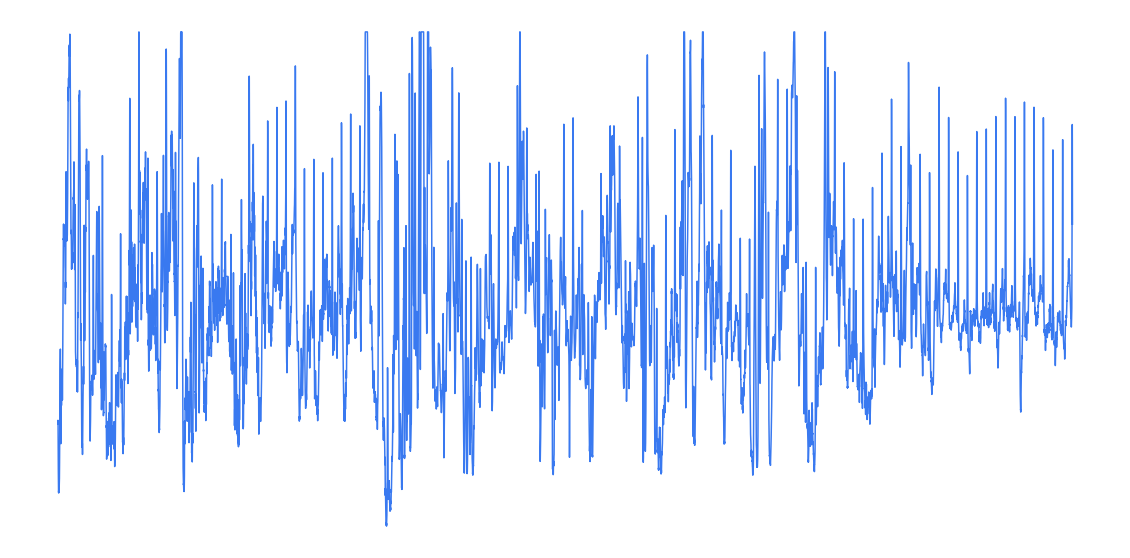

Finishing data 52 1


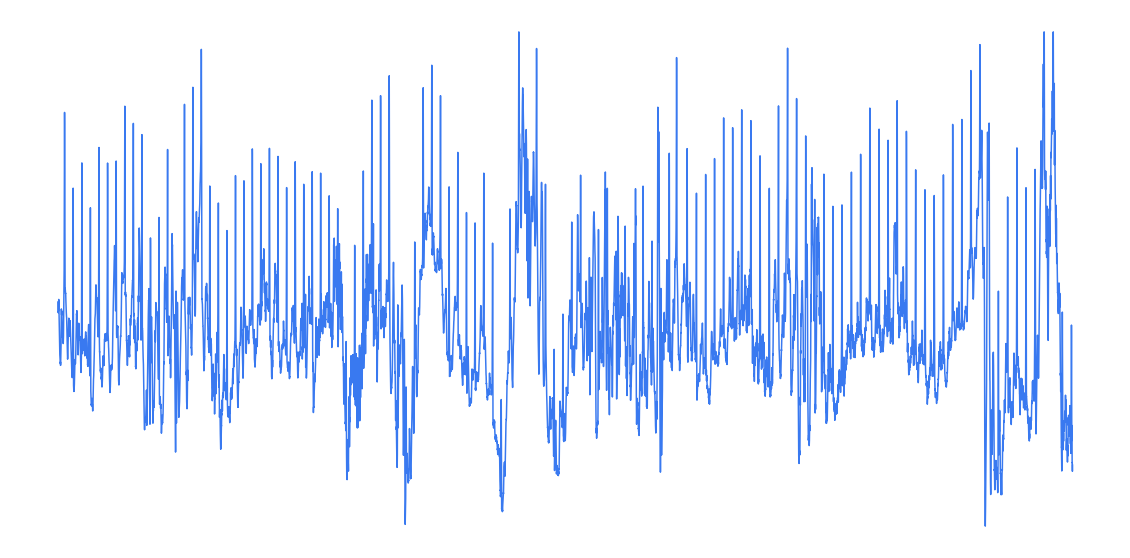

Finishing data 52 2
Finishing data 52


In [14]:
for i in range(0, len(lines)):
    val = vf_dt.loc[i,  'VF Onset Time (elapsed)'] # Take VF onset time
    v = lines[i]

    # get time of VF the data
    hour = int(val[0:2])*3600000
    minute = int(val[3:5])*60000
    second = int(val[6:8])*1000

    VF = hour + minute + second # Total length of time

    # need to convert to signal len. 1 time = 4 mili second
    VF = VF/4
    
    directory = "Data/sudden-cardiac-death-holter-database-1.0.0/"+v
    print(directory)

    # looping 2x
    for itr in range(1,3):
        # Calculate time of start and finish 
        record = wfdb.rdrecord(directory)
        time = record.sig_len # Get length of time

        # Setup value of time frame
        m = (1000*60)/4 # times value, 30 second

        # setup time start and finish
        start = int(VF-(m*itr)) # start time is VF minus time value
        finish = int(VF-(m*(itr-1)))# take from VF onset time

        saveImage(v, itr, directory, record, start, finish, 'Timeseries-SCD')
    print('Finishing data '+str(v))

### Result of the data is Grayscale picture that save on folder 'Grayscale'